In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df= pd.read_csv('dataset/unemployment in india.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.shape
df.columns


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-05-2019    Monthly                              3.65   
1    Andhra Pradesh   30-06-2019    Monthly                              3.05   
2    Andhra Pradesh   31-07-2019    Monthly                              3.75   
3    Andhra Pradesh   31-08-2019    Monthly                              3.32   
4    Andhra Pradesh   30-09-2019    Monthly                              5.17   
..              ...          ...        ...                               ...   
763             NaN          NaN        NaN                               NaN   
764             NaN          NaN        NaN                               NaN   
765             NaN          NaN        NaN                               NaN   
766             NaN          NaN        NaN                               NaN   
767             NaN          NaN        NaN                               NaN

In [19]:
df.describe 

<bound method NDFrame.describe of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-05-2019    Monthly                              3.65   
1    Andhra Pradesh   30-06-2019    Monthly                              3.05   
2    Andhra Pradesh   31-07-2019    Monthly                              3.75   
3    Andhra Pradesh   31-08-2019    Monthly                              3.32   
4    Andhra Pradesh   30-09-2019    Monthly                              5.17   
..              ...          ...        ...                               ...   
763             NaN          NaN        NaN                               NaN   
764             NaN          NaN        NaN                               NaN   
765             NaN          NaN        NaN                               NaN   
766             NaN          NaN        NaN                               NaN   
767             NaN          NaN        NaN                               N

In [20]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(27)

In [25]:
df.dtypes

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

In [26]:
df_raw= df.copy()

In [28]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [31]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [32]:
missing = df.isnull().sum()

print(missing)


Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [33]:
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

print(missing_percent)

Region                                     3.65
Date                                       3.65
Frequency                                  3.65
Estimated Unemployment Rate (%)            3.65
Estimated Employed                         3.65
Estimated Labour Participation Rate (%)    3.65
Area                                       3.65
dtype: float64


In [37]:
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df = df.dropna()
print(df.isnull().sum().sum())

0


In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [42]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df['Date'].dtype)

datetime64[ns]


In [43]:
print("Invalid dates:", df['Date'].isnull().sum())

Invalid dates: 0


In [44]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

In [45]:
numeric_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [46]:
df[numeric_cols].dtypes

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [48]:
df.shape

(740, 7)

In [50]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [51]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [52]:
df[df['Estimated Unemployment Rate (%)'] < 0]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area


In [53]:
df['Estimated Unemployment Rate (%)'].describe()

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64

In [54]:
print("Regions:")
print(df['Region'].unique())

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [55]:
print("\nFrequency:")
print(df['Frequency'].unique())


Frequency:
['Monthly']


In [56]:
print("\nArea:")
print(df['Area'].unique())


Area:
['Rural' 'Urban']


In [57]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

In [58]:
df[['Date', 'Year', 'Month', 'Month_Name']].head()

,Date,Year,Month,Month_Name
0,2019-05-31,2019,5,May
1,2019-06-30,2019,6,June
2,2019-07-31,2019,7,July
3,2019-08-31,2019,8,August
4,2019-09-30,2019,9,September


In [59]:
print("DATA QUALITY CHECK")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("Invalid dates:", df['Date'].isnull().sum())

print("Negative unemployment values:",
      (df['Estimated Unemployment Rate (%)'] < 0).sum())



DATA QUALITY CHECK
Rows: 740
Columns: 10
Missing values: 0
Duplicate rows: 0
Invalid dates: 0
Negative unemployment values: 0


In [60]:
df.to_csv(
    'cleaned_data/cleaned_unemployment.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Exploratory Data Analysis and Statistical Analysis

In [61]:
df = pd.read_csv("cleaned_data/cleaned_unemployment.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


In [62]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 740
Number of columns: 10


In [63]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year,Month
count,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,11.787946,7.204460e+06,42.630122,2019.418919,6.390541
std,10.721298,8.087988e+06,8.111094,0.493716,3.235070
min,0.000000,4.942000e+04,13.330000,2019.000000,1.000000
25%,4.657500,1.190404e+06,38.062500,2019.000000,4.000000
50%,8.350000,4.744178e+06,41.160000,2019.000000,6.000000
75%,15.887500,1.127549e+07,45.505000,2020.000000,9.000000
max,76.740000,4.577751e+07,72.570000,2020.000000,12.000000


In [64]:
unemployment = df['Estimated Unemployment Rate (%)']

print("Mean:", unemployment.mean())
print("Median:", unemployment.median())
print("Minimum:", unemployment.min())
print("Maximum:", unemployment.max())
print("Standard Deviation:", unemployment.std())

Mean: 11.787945945945946
Median: 8.35
Minimum: 0.0
Maximum: 76.74
Standard Deviation: 10.721298373157783


In [65]:
unemployment.describe()

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64

In [66]:
max_unemployment = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmax()
]

max_unemployment

Region                                     Puducherry
Date                                       2020-04-30
Frequency                                     Monthly
Estimated Unemployment Rate (%)                 76.74
Estimated Employed                            68122.0
Estimated Labour Participation Rate (%)         35.54
Area                                            Urban
Year                                             2020
Month                                               4
Month_Name                                      April
Name: 613, dtype: object

In [67]:
print("Region:", max_unemployment['Region'])
print("Date:", max_unemployment['Date'])
print(
    "Unemployment Rate:",
    max_unemployment['Estimated Unemployment Rate (%)']
)

Region: Puducherry
Date: 2020-04-30
Unemployment Rate: 76.74


In [68]:
min_unemployment = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmin()
]

min_unemployment

Region                                          Assam
Date                                       2020-06-30
Frequency                                     Monthly
Estimated Unemployment Rate (%)                   0.0
Estimated Employed                          7544937.0
Estimated Labour Participation Rate (%)         34.38
Area                                            Rural
Year                                             2020
Month                                               6
Month_Name                                       June
Name: 25, dtype: object

In [69]:
print("Region:", min_unemployment['Region'])
print("Date:", min_unemployment['Date'])
print(
    "Unemployment Rate:",
    min_unemployment['Estimated Unemployment Rate (%)']
)

Region: Assam
Date: 2020-06-30
Unemployment Rate: 0.0


In [70]:
top_10_unemployment = df.nlargest(
    10,
    'Estimated Unemployment Rate (%)'
)

top_10_unemployment[
    [
        'Region',
        'Date',
        'Estimated Unemployment Rate (%)',
        'Area'
    ]
]

,Region,Date,Estimated Unemployment Rate (%),Area
613,Puducherry,2020-04-30,76.74,Urban
614,Puducherry,2020-05-31,75.00,Urban
242,Puducherry,2020-04-30,74.51,Rural
517,Jharkhand,2020-05-31,70.17,Urban
516,Jharkhand,2020-04-30,61.48,Urban
398,Bihar,2020-04-30,58.77,Urban
145,Jharkhand,2020-05-31,55.10,Rural
287,Tamil Nadu,2020-04-30,53.19,Rural
493,Himachal Pradesh,2020-05-31,50.00,Urban
38,Bihar,2020-05-31,47.26,Rural


In [71]:
bottom_10_unemployment = df.nsmallest(
    10,
    'Estimated Unemployment Rate (%)'
)

bottom_10_unemployment[
    [
        'Region',
        'Date',
        'Estimated Unemployment Rate (%)',
        'Area'
    ]
]

,Region,Date,Estimated Unemployment Rate (%),Area
25,Assam,2020-06-30,0.0,Rural
51,Chhattisgarh,2020-04-30,0.0,Rural
77,Goa,2020-02-29,0.0,Rural
231,Puducherry,2019-05-31,0.0,Rural
232,Puducherry,2019-06-30,0.0,Rural
233,Puducherry,2019-07-31,0.0,Rural
235,Puducherry,2019-09-30,0.0,Rural
237,Puducherry,2019-11-30,0.0,Rural
274,Sikkim,2020-04-30,0.0,Rural
603,Puducherry,2019-06-30,0.0,Urban


In [72]:
print("Number of regions:", df['Region'].nunique())

Number of regions: 28


In [74]:
print(df['Region'].unique())

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [75]:
df['Region'].value_counts()

Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64

In [76]:
df['Area'].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [77]:
area_unemployment = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

area_unemployment

,mean,median,min,max
Area,,,,
Rural,10.32,6.76,0.0,74.51
Urban,13.17,9.97,0.0,76.74


Average unemployment by region

In [78]:
regional_stats = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
      .round(2)
)

regional_stats

,mean,median,min,max
Region,,,,
Tripura,28.35,27.31,14.71,43.64
Haryana,26.28,25.06,14.54,46.89
Jharkhand,20.58,17.28,5.01,70.17
Bihar,18.92,15.01,8.87,58.77
Himachal Pradesh,18.54,18.35,1.12,50.00
Delhi,16.50,15.02,9.33,45.78
Jammu & Kashmir,16.19,16.00,2.22,24.06
Chandigarh,15.99,17.51,7.22,22.05
Rajasthan,14.06,13.66,4.03,35.53


Average employment by region

In [79]:
regional_employment = (
    df.groupby('Region')['Estimated Employed']
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

regional_employment

Region
Uttar Pradesh       28094832.18
Maharashtra         19990195.86
West Bengal         17198538.00
Bihar               12366189.14
Tamil Nadu          12269546.75
Gujarat             11402012.79
Madhya Pradesh      11115484.32
Karnataka           10667119.29
Rajasthan           10041064.75
Andhra Pradesh       8154093.18
Telangana            7939662.75
Odisha               6545746.96
Assam                5354772.15
Punjab               4539362.00
Jharkhand            4469240.43
Kerala               4425899.50
Chhattisgarh         4303498.57
Haryana              3557072.46
Delhi                2627512.86
Jammu & Kashmir      1799931.67
Uttarakhand          1390228.11
Himachal Pradesh     1059823.71
Tripura               717002.64
Meghalaya             689736.81
Chandigarh            316831.25
Goa                   226308.33
Puducherry            212278.08
Sikkim                106880.71
Name: Estimated Employed, dtype: float64

Labour participation by region

In [80]:
regional_participation = (
    df.groupby('Region')[
        'Estimated Labour Participation Rate (%)'
    ]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

regional_participation

Region
Tripura             61.82
Meghalaya           57.08
Telangana           53.00
Gujarat             46.10
Sikkim              46.07
West Bengal         45.42
Assam               44.87
Himachal Pradesh    44.22
Chhattisgarh        42.81
Haryana             42.74
Maharashtra         42.30
Jharkhand           41.67
Karnataka           41.35
Punjab              41.14
Jammu & Kashmir     41.03
Tamil Nadu          40.87
Rajasthan           39.97
Uttar Pradesh       39.43
Andhra Pradesh      39.38
Chandigarh          39.34
Goa                 39.25
Puducherry          38.99
Delhi               38.93
Odisha              38.93
Madhya Pradesh      38.82
Bihar               38.15
Kerala              34.87
Uttarakhand         33.78
Name: Estimated Labour Participation Rate (%), dtype: float64

Year-wise unemployment analysis

In [81]:
yearly_unemployment = (
    df.groupby('Year')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

yearly_unemployment

,mean,median,min,max
Year,,,,
2019,9.4,7.12,0.0,34.69
2020,15.1,10.79,0.0,76.74


Year-wise employment

In [82]:
yearly_employment = (
    df.groupby('Year')['Estimated Employed']
      .mean()
      .round(2)
)

yearly_employment

Year
2019    7422976.47
2020    6901356.57
Name: Estimated Employed, dtype: float64

Year-wise labour participation

In [83]:
yearly_participation = (
    df.groupby('Year')[
        'Estimated Labour Participation Rate (%)'
    ]
    .mean()
    .round(2)
)

yearly_participation

Year
2019    43.89
2020    40.89
Name: Estimated Labour Participation Rate (%), dtype: float64

Monthly unemployment analysis

In [84]:
monthly_unemployment = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
      .mean()
      .round(2)
)

monthly_unemployment

Month
1      9.95
2      9.96
3     10.70
4     23.64
5     16.65
6     10.55
7      9.03
8      9.64
9      9.05
10     9.90
11     9.87
12     9.50
Name: Estimated Unemployment Rate (%), dtype: float64

complete analytical summary

In [85]:
analysis_summary = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Median_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'median'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    ),
    Average_Labour_Participation=(
        'Estimated Labour Participation Rate (%)',
        'mean'
    )
).round(2)

analysis_summary

,Average_Unemployment,Median_Unemployment,Average_Employment,Average_Labour_Participation
Region,,,,
Andhra Pradesh,7.48,5.40,8154093.18,39.38
Assam,6.43,5.44,5354772.15,44.87
Bihar,18.92,15.01,12366189.14,38.15
Chandigarh,15.99,17.51,316831.25,39.34
Chhattisgarh,9.24,8.26,4303498.57,42.81
Delhi,16.50,15.02,2627512.86,38.93
Goa,9.27,6.33,226308.33,39.25
Gujarat,6.66,5.42,11402012.79,46.10
Haryana,26.28,25.06,3557072.46,42.74


*Distribution of Unemployment Rate*

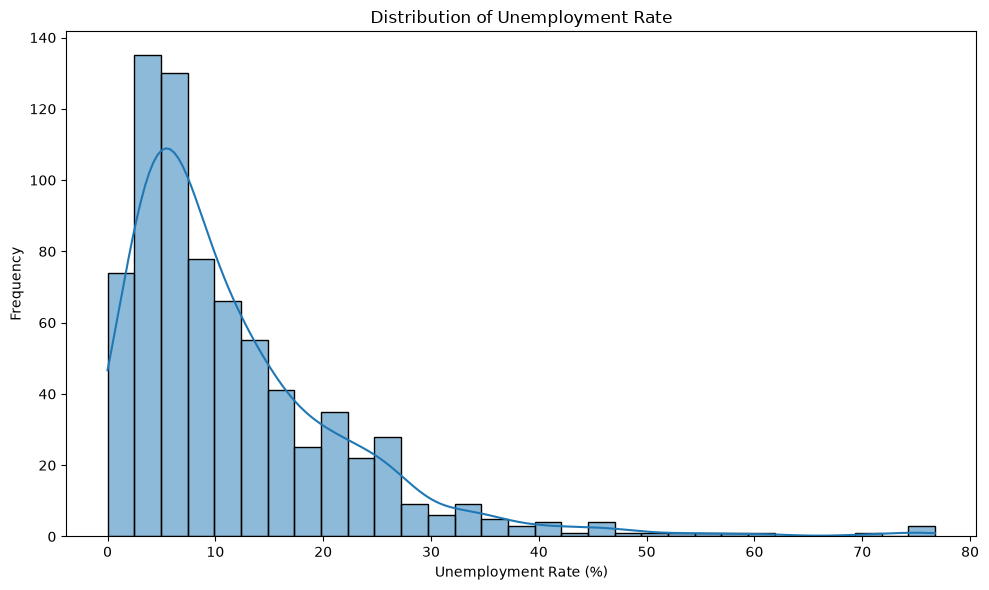

In [86]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    kde=True
)

plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

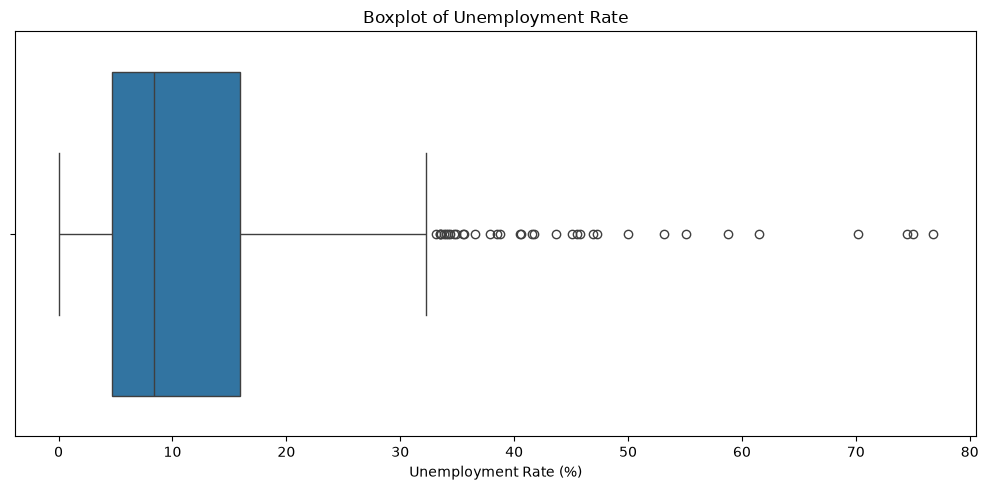

In [87]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df['Estimated Unemployment Rate (%)']
)

plt.title('Boxplot of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

In [88]:
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


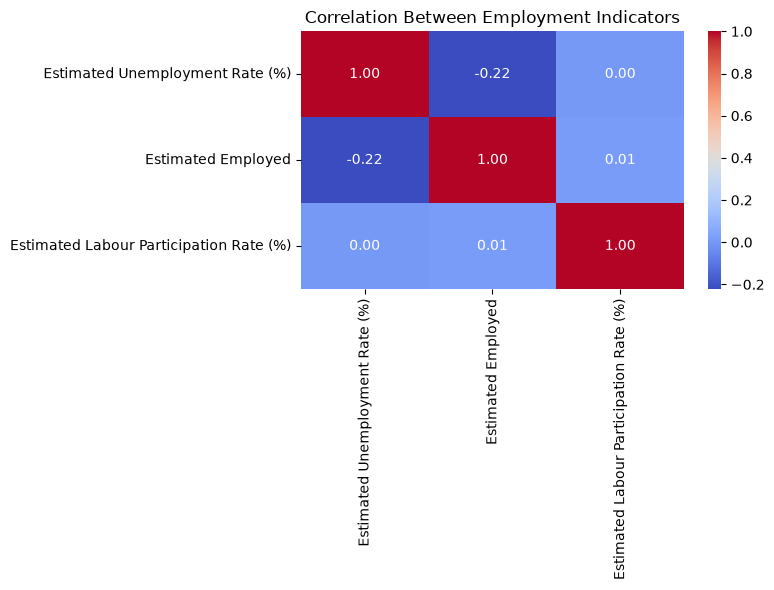

In [90]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

### Distribution Analysis

The unemployment rate distribution is positively skewed (right-skewed). Most observations are concentrated at relatively lower unemployment rates, while a smaller number of observations have substantially higher unemployment rates. This indicates the presence of extreme unemployment observations in the dataset.

### Outlier Analysis

The boxplot shows several observations beyond the upper whisker, indicating potential outliers in the unemployment-rate data. These observations were retained because an unusually high unemployment rate may represent a genuine economic condition rather than a data-entry error. Further time-based analysis is required to understand the reasons behind these extreme values.

### Correlation Analysis

The correlation analysis shows a weak negative relationship (-0.22) between the estimated unemployment rate and estimated employment. This suggests that higher unemployment observations are somewhat associated with lower employment values, although the relationship is weak.

The correlation between unemployment rate and labour participation rate is approximately zero (0.00), indicating no meaningful linear relationship between these variables in the dataset.

Similarly, estimated employment and labour participation rate have an approximately zero correlation (0.01).

These correlations describe relationships observed in the dataset and should not be interpreted as evidence of causation.

Year-wise unemployment

In [91]:
yearly_unemployment = (
    df.groupby('Year')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

yearly_unemployment

,mean,median,min,max
Year,,,,
2019,9.4,7.12,0.0,34.69
2020,15.1,10.79,0.0,76.74


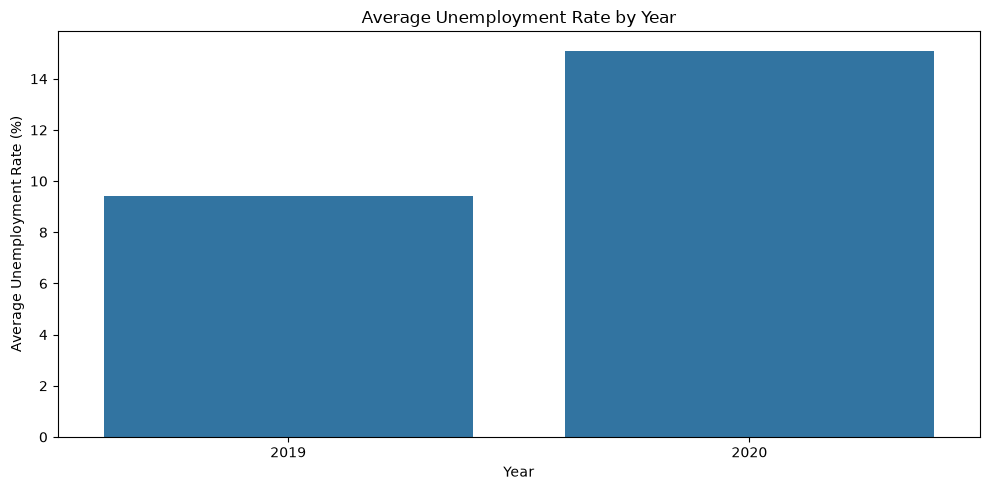

In [92]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=yearly_unemployment.index,
    y=yearly_unemployment['mean']
)

plt.title('Average Unemployment Rate by Year')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

Monthly unemployment

In [93]:
monthly_unemployment = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
      .mean()
      .round(2)
)

monthly_unemployment

Month
1      9.95
2      9.96
3     10.70
4     23.64
5     16.65
6     10.55
7      9.03
8      9.64
9      9.05
10     9.90
11     9.87
12     9.50
Name: Estimated Unemployment Rate (%), dtype: float64

In [94]:
month_names = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_unemployment.index = [
    month_names[i-1] for i in monthly_unemployment.index
]

monthly_unemployment

January       9.95
February      9.96
March        10.70
April        23.64
May          16.65
June         10.55
July          9.03
August        9.64
September     9.05
October       9.90
November      9.87
December      9.50
Name: Estimated Unemployment Rate (%), dtype: float64

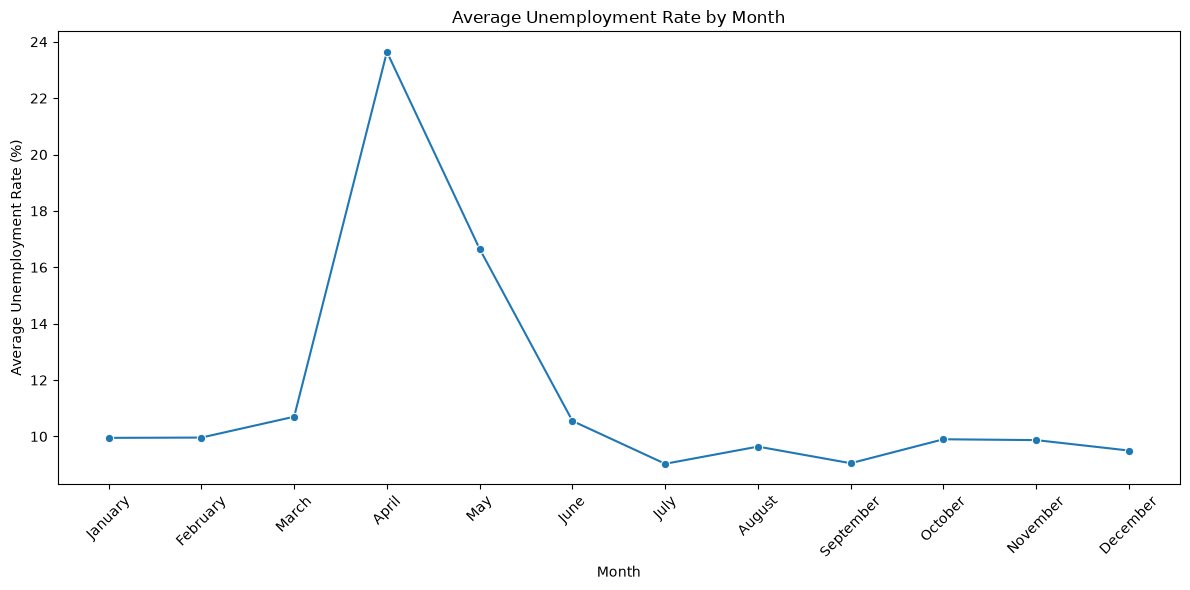

In [95]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_unemployment.index,
    y=monthly_unemployment.values,
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Urban vs Rural

In [96]:
area_analysis = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

area_analysis

,mean,median,min,max
Area,,,,
Rural,10.32,6.76,0.0,74.51
Urban,13.17,9.97,0.0,76.74


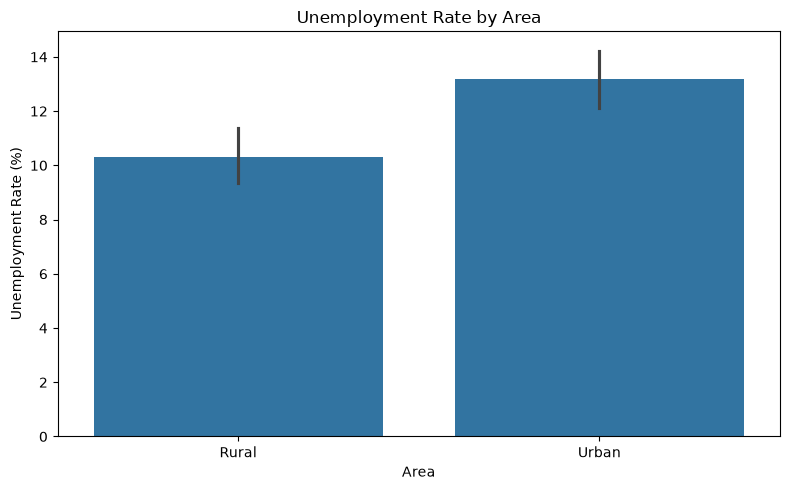

In [97]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

Regional analysis

In [98]:
regional_analysis = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
      .round(2)
)

regional_analysis

,mean,median,min,max
Region,,,,
Tripura,28.35,27.31,14.71,43.64
Haryana,26.28,25.06,14.54,46.89
Jharkhand,20.58,17.28,5.01,70.17
Bihar,18.92,15.01,8.87,58.77
Himachal Pradesh,18.54,18.35,1.12,50.00
Delhi,16.50,15.02,9.33,45.78
Jammu & Kashmir,16.19,16.00,2.22,24.06
Chandigarh,15.99,17.51,7.22,22.05
Rajasthan,14.06,13.66,4.03,35.53


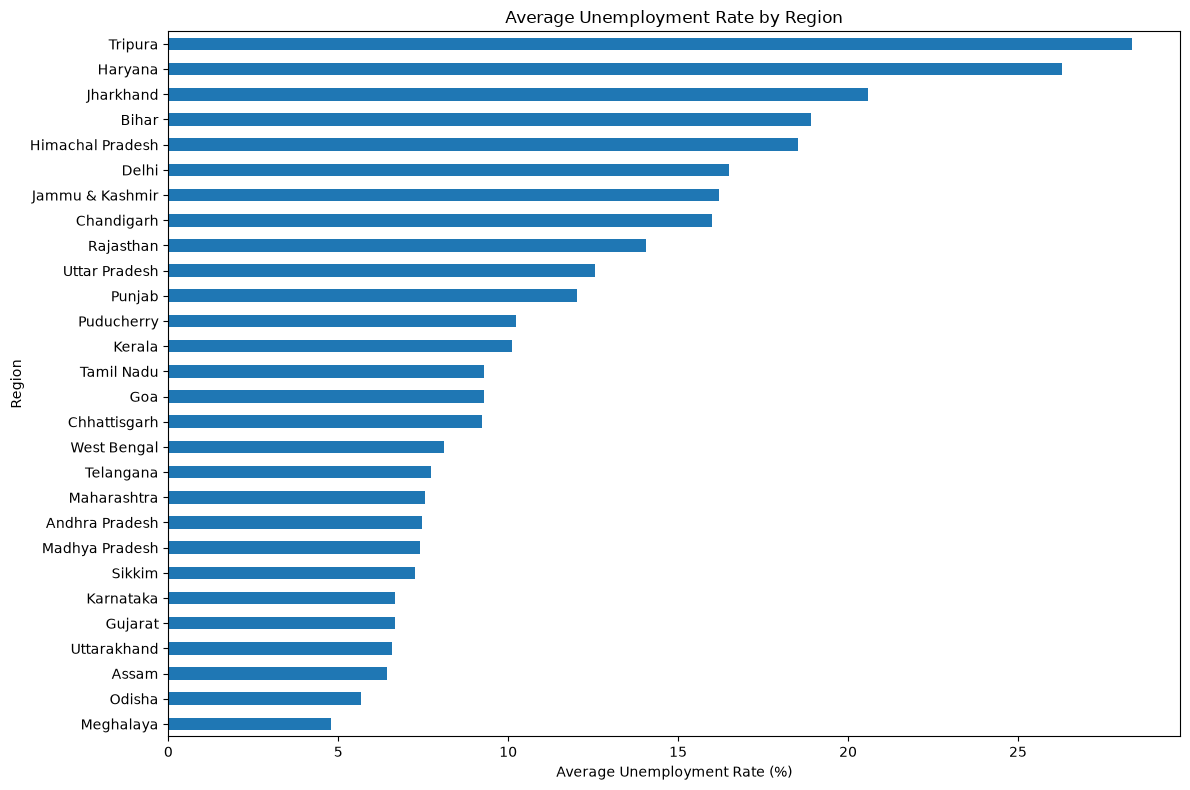

In [99]:
plt.figure(figsize=(12, 8))

regional_mean = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values()
)

regional_mean.plot(kind='barh')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [100]:
eda_summary = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Median_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'median'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    ),
    Average_Labour_Participation=(
        'Estimated Labour Participation Rate (%)',
        'mean'
    )
).round(2)

eda_summary

,Average_Unemployment,Median_Unemployment,Average_Employment,Average_Labour_Participation
Region,,,,
Andhra Pradesh,7.48,5.40,8154093.18,39.38
Assam,6.43,5.44,5354772.15,44.87
Bihar,18.92,15.01,12366189.14,38.15
Chandigarh,15.99,17.51,316831.25,39.34
Chhattisgarh,9.24,8.26,4303498.57,42.81
Delhi,16.50,15.02,2627512.86,38.93
Goa,9.27,6.33,226308.33,39.25
Gujarat,6.66,5.42,11402012.79,46.10
Haryana,26.28,25.06,3557072.46,42.74


## Time-Series Analysis

Time-series analysis is used to understand how unemployment changes over time. In this section, monthly unemployment trends are analyzed to identify increases, decreases, unusual changes, and the impact of the COVID-19 period.

In [101]:
monthly_trend = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)

monthly_trend

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731
5,2019-10-31,9.900909
6,2019-11-30,9.868364
7,2019-12-31,9.497358
8,2020-01-31,9.950755
9,2020-02-29,9.964717


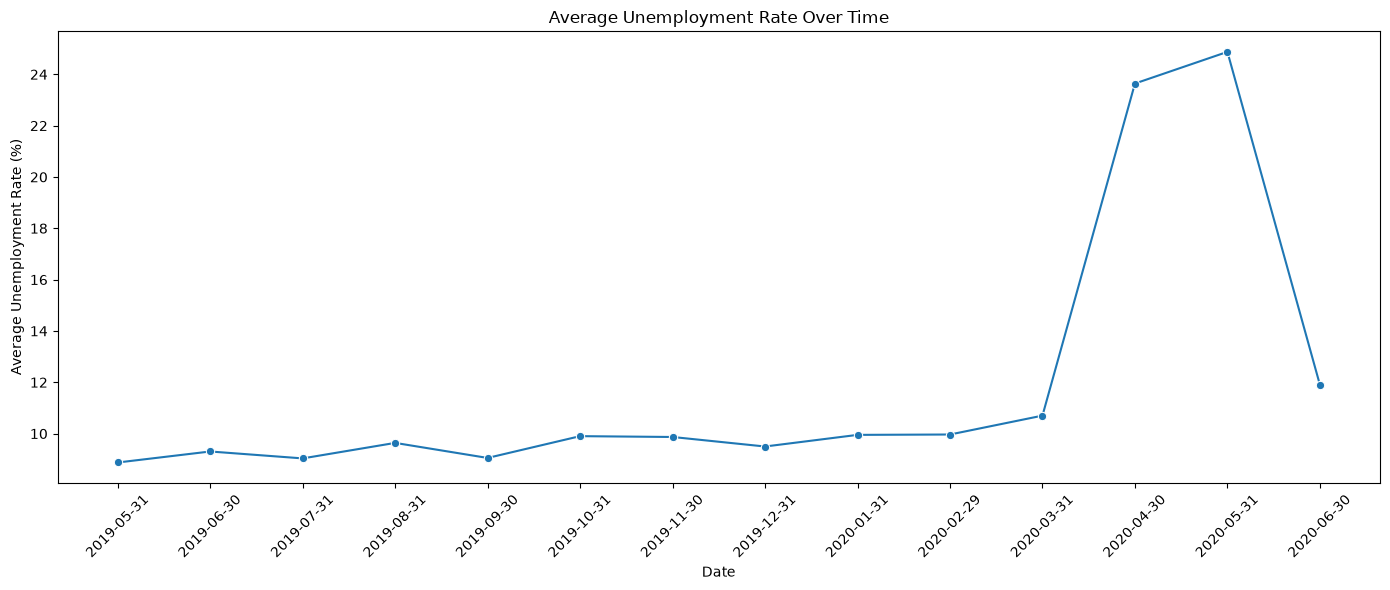

In [102]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_trend,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
monthly_trend['3_Month_Moving_Average'] = (
    monthly_trend['Estimated Unemployment Rate (%)']
    .rolling(window=3)
    .mean()
)

monthly_trend

,Date,Estimated Unemployment Rate (%),3_Month_Moving_Average
0,2019-05-31,8.874259,NaN
1,2019-06-30,9.303333,NaN
2,2019-07-31,9.033889,9.070494
3,2019-08-31,9.637925,9.325049
4,2019-09-30,9.051731,9.241181
5,2019-10-31,9.900909,9.530188
6,2019-11-30,9.868364,9.607001
7,2019-12-31,9.497358,9.755544
8,2020-01-31,9.950755,9.772159
9,2020-02-29,9.964717,9.804277


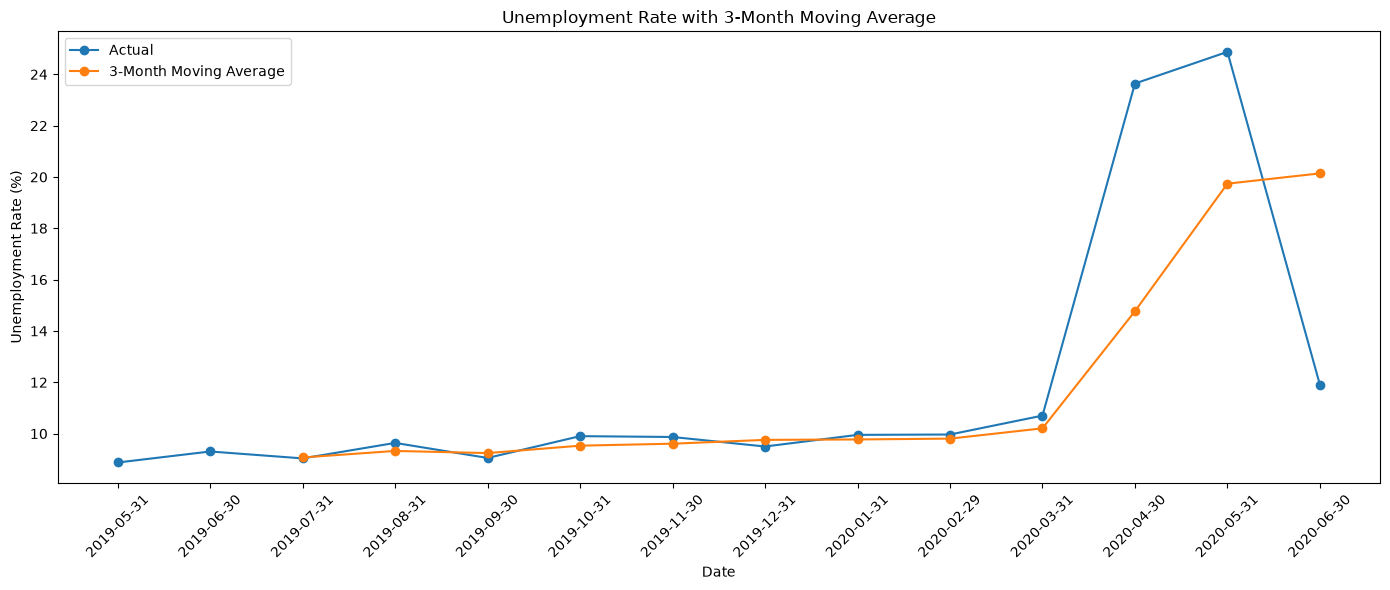

In [105]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend['Date'],
    monthly_trend['Estimated Unemployment Rate (%)'],
    marker='o',
    label='Actual'
)

plt.plot(
    monthly_trend['Date'],
    monthly_trend['3_Month_Moving_Average'],
    marker='o',
    label='3-Month Moving Average'
)

plt.title('Unemployment Rate with 3-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

highest unemployment month

In [106]:
highest_month = monthly_trend.loc[
    monthly_trend['Estimated Unemployment Rate (%)'].idxmax()
]

highest_month

Date                               2020-05-31
Estimated Unemployment Rate (%)     24.875294
3_Month_Moving_Average              19.739147
Name: 12, dtype: object

In [109]:
print(
    "Highest average unemployment:",
    round(highest_month['Estimated Unemployment Rate (%)'], 2),
    "%"
)

date_value = pd.to_datetime(highest_month['Date'])
print(
    "Date:",
    date_value.strftime('%B %Y')
)

Highest average unemployment: 24.88 %
Date: May 2020


lowest unemployment month

In [111]:
lowest_month = monthly_trend.loc[
    monthly_trend['Estimated Unemployment Rate (%)'].idxmin()
]

print(
    "Lowest average unemployment:",
    round(lowest_month['Estimated Unemployment Rate (%)'], 2),
    "%"
)

date_value = pd.to_datetime(lowest_month['Date'])
print(
    "Date:",
    date_value.strftime('%B %Y')
)

Lowest average unemployment: 8.87 %
Date: May 2019


In [115]:
monthly_trend['MoM_Change'] = (
    monthly_trend['Estimated Unemployment Rate (%)']
    .diff()
)
monthly_trend

,Date,Estimated Unemployment Rate (%),3_Month_Moving_Average,MoM_Change,MoM_Percentage_Change
0,2019-05-31,8.874259,NaN,NaN,NaN
1,2019-06-30,9.303333,NaN,0.429074,4.835041
2,2019-07-31,9.033889,9.070494,-0.269444,-2.896214
3,2019-08-31,9.637925,9.325049,0.604036,6.686330
4,2019-09-30,9.051731,9.241181,-0.586194,-6.082158
5,2019-10-31,9.900909,9.530188,0.849178,9.381392
6,2019-11-30,9.868364,9.607001,-0.032545,-0.328712
7,2019-12-31,9.497358,9.755544,-0.371005,-3.759541
8,2020-01-31,9.950755,9.772159,0.453396,4.773919
9,2020-02-29,9.964717,9.804277,0.013962,0.140314


In [114]:
monthly_trend['MoM_Percentage_Change'] = (
    monthly_trend['Estimated Unemployment Rate (%)']
    .pct_change() * 100
)
monthly_trend

,Date,Estimated Unemployment Rate (%),3_Month_Moving_Average,MoM_Change,MoM_Percentage_Change
0,2019-05-31,8.874259,NaN,NaN,NaN
1,2019-06-30,9.303333,NaN,0.429074,4.835041
2,2019-07-31,9.033889,9.070494,-0.269444,-2.896214
3,2019-08-31,9.637925,9.325049,0.604036,6.686330
4,2019-09-30,9.051731,9.241181,-0.586194,-6.082158
5,2019-10-31,9.900909,9.530188,0.849178,9.381392
6,2019-11-30,9.868364,9.607001,-0.032545,-0.328712
7,2019-12-31,9.497358,9.755544,-0.371005,-3.759541
8,2020-01-31,9.950755,9.772159,0.453396,4.773919
9,2020-02-29,9.964717,9.804277,0.013962,0.140314


In [116]:
largest_increase = monthly_trend.loc[
    monthly_trend['MoM_Change'].idxmax()
]

largest_increase

Date                               2020-04-30
Estimated Unemployment Rate (%)     23.641569
3_Month_Moving_Average              14.768954
MoM_Change                          12.940992
MoM_Percentage_Change              120.937327
Name: 11, dtype: object

In [117]:
largest_decrease = monthly_trend.loc[
    monthly_trend['MoM_Change'].idxmin()
]

largest_decrease

Date                               2020-06-30
Estimated Unemployment Rate (%)       11.9036
3_Month_Moving_Average              20.140154
MoM_Change                         -12.971694
MoM_Percentage_Change              -52.146897
Name: 13, dtype: object

In [118]:
pre_covid = df[
    df['Date'] < '2020-03-01'
]

covid_period = df[
    df['Date'] >= '2020-03-01'
]

In [119]:
pre_covid_avg = (
    pre_covid['Estimated Unemployment Rate (%)'].mean()
)

covid_avg = (
    covid_period['Estimated Unemployment Rate (%)'].mean()
)

print(f"Pre-COVID average: {pre_covid_avg:.2f}%")
print(f"COVID-period average: {covid_avg:.2f}%")

Pre-COVID average: 9.51%
COVID-period average: 17.77%


In [120]:
absolute_change = covid_avg - pre_covid_avg

print(
    f"Absolute change: {absolute_change:.2f} percentage points"
)

Absolute change: 8.26 percentage points


In [121]:
percentage_change = (
    (covid_avg - pre_covid_avg)
    / pre_covid_avg
) * 100

print(
    f"Percentage change: {percentage_change:.2f}%"
)

Percentage change: 86.91%


COVID comparison chart

In [122]:
covid_comparison = pd.DataFrame({
    'Period': ['Pre-COVID', 'COVID Period'],
    'Average Unemployment Rate': [
        pre_covid_avg,
        covid_avg
    ]
})

covid_comparison

,Period,Average Unemployment Rate
0,Pre-COVID,9.509534
1,COVID Period,17.774363


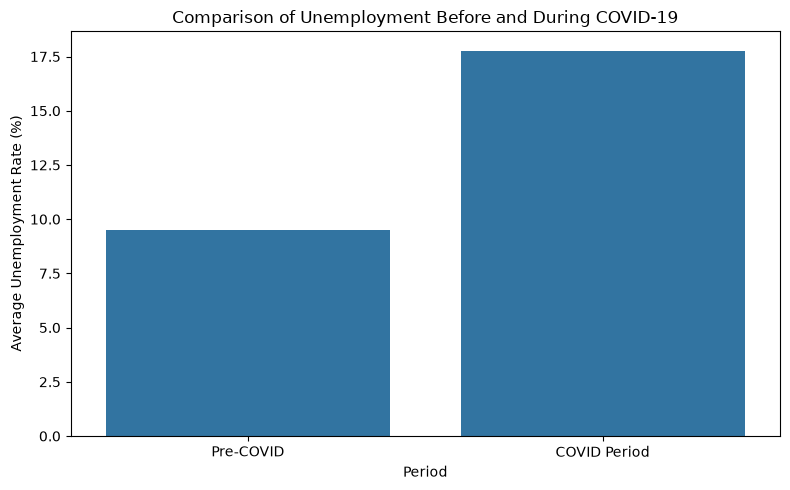

In [123]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Average Unemployment Rate'
)

plt.title('Comparison of Unemployment Before and During COVID-19')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

ConversionError: Failed to convert value(s) to axis units: Timestamp('2020-03-01 00:00:00')

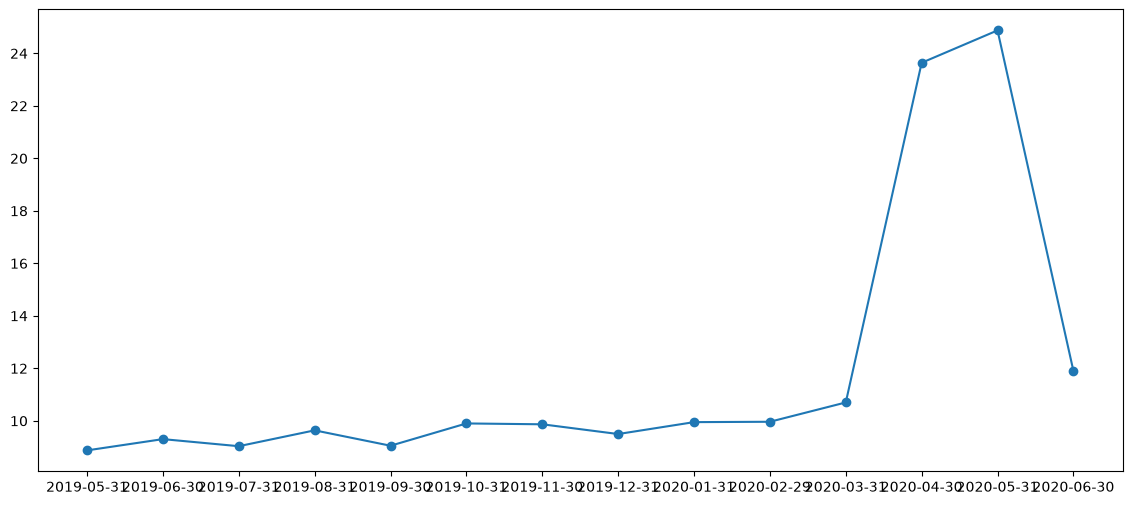

In [125]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend['Date'],
    monthly_trend['Estimated Unemployment Rate (%)'],
    marker='o',
    label='Unemployment Rate'
)

plt.axvline(
    pd.Timestamp('2020-03-01'),
    linestyle='--',
    label='COVID Period Begins'
)

plt.title('Unemployment Trend and COVID-19 Period')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

COVID analysis by region

In [126]:
regional_pre_covid = (
    pre_covid
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

In [127]:
regional_covid = (
    covid_period
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

In [128]:
regional_covid_analysis = pd.concat(
    [
        regional_pre_covid.rename('Pre_COVID'),
        regional_covid.rename('COVID_Period')
    ],
    axis=1
)

In [129]:
regional_covid_analysis['Absolute_Change'] = (
    regional_covid_analysis['COVID_Period']
    - regional_covid_analysis['Pre_COVID']
)

In [130]:
regional_covid_analysis['Percentage_Change'] = (
    regional_covid_analysis['Absolute_Change']
    / regional_covid_analysis['Pre_COVID']
) * 100

In [131]:
regional_covid_analysis = (
    regional_covid_analysis
    .sort_values('Absolute_Change', ascending=False)
    .round(2)
)

regional_covid_analysis

,Pre_COVID,COVID_Period,Absolute_Change,Percentage_Change
Region,,,,
Puducherry,1.59,38.96,37.36,2345.39
Tamil Nadu,2.84,25.40,22.57,795.60
Jharkhand,14.28,36.35,22.07,154.55
Bihar,13.83,31.63,17.80,128.67
Karnataka,3.23,15.28,12.05,372.41
Haryana,22.94,34.65,11.72,51.09
Kerala,6.99,17.95,10.96,156.74
Telangana,4.66,15.44,10.79,231.67
Madhya Pradesh,4.74,14.07,9.33,196.77


COVID impact visualization by region

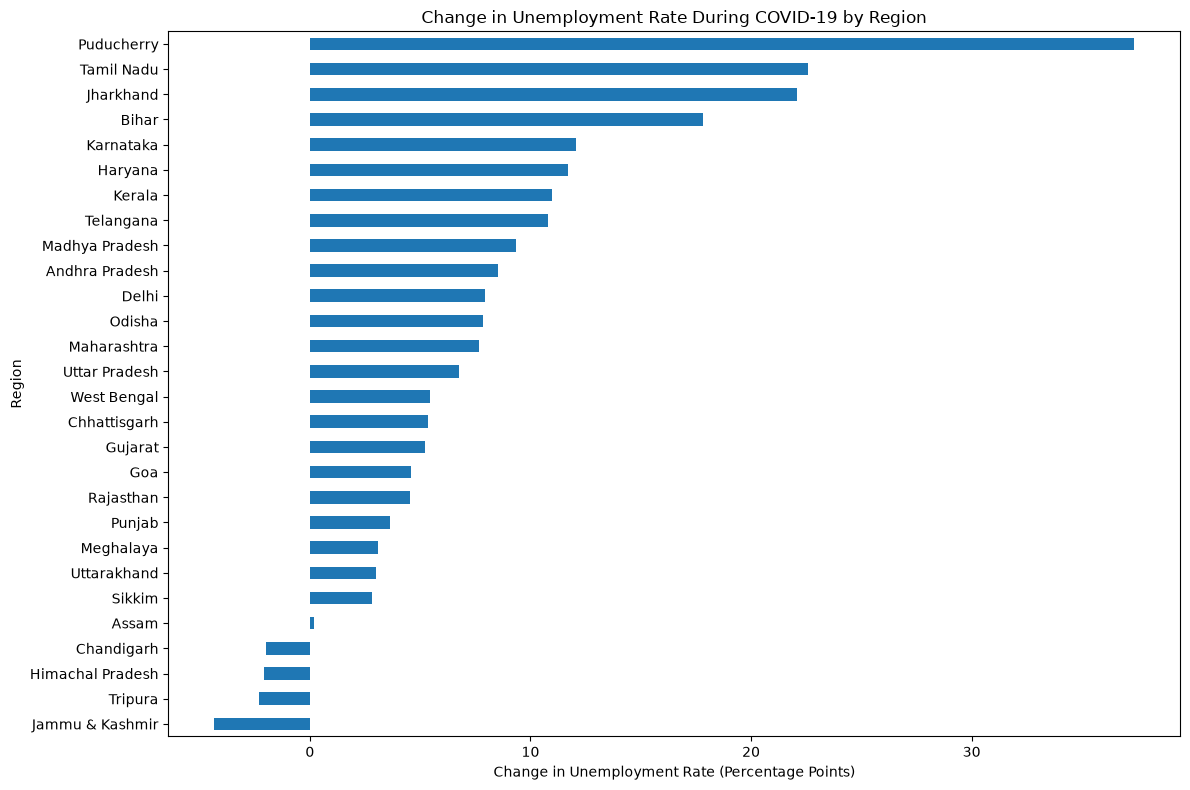

In [132]:
plt.figure(figsize=(12, 8))

regional_covid_analysis['Absolute_Change'].sort_values().plot(
    kind='barh'
)

plt.title('Change in Unemployment Rate During COVID-19 by Region')
plt.xlabel('Change in Unemployment Rate (Percentage Points)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [133]:
monthly_trend.to_csv(
    'analysis_results/monthly_unemployment_trend.csv',
    index=False
)

regional_covid_analysis.to_csv(
    'analysis_results/regional_covid_analysis.csv'
)

### Preliminary Time-Series Finding

The dataset covers May 2019 to June 2020. The average unemployment rate was approximately 9.40% during the observations available for 2019 and 15.10% during the observations available for 2020. The monthly trend shows a pronounced increase in unemployment during the early months of the COVID-19 period, with April 2020 showing a particularly high average unemployment rate.

Because the dataset ends in June 2020, it does not provide sufficient observations to evaluate a longer-term post-COVID recovery.

### Time-Series Findings

The unemployment rate remained relatively stable during most of the period from May 2019 to February 2020, generally remaining around 9–10%.

A substantial increase occurred in March and April 2020. The average unemployment rate increased from 10.70% in March 2020 to 23.64% in April 2020, representing an increase of approximately 12.94 percentage points.

The unemployment rate reached 24.88% in May 2020, the highest monthly average in the dataset. It then declined to 11.90% in June 2020.

The sharp increase during April and May 2020 coincides with the COVID-19 period covered by the dataset. However, the analysis describes an observed temporal association and does not by itself establish that COVID-19 was the sole cause of the change.

### Moving Average Analysis

The 3-month moving average provides a smoother representation of the unemployment trend. The moving average increased considerably during the early months of 2020, reaching approximately 20.14% by June 2020. This indicates that the increase in unemployment affected the broader short-term trend rather than representing only a single monthly observation.

### Regional COVID Findings

The regional analysis shows that changes in unemployment were not uniform across all regions. Many regions experienced substantial increases in their average unemployment rates during the COVID-period observations, while a smaller number of regions recorded decreases.

This indicates considerable regional variation in the unemployment response during the period analyzed.

# Regional and Urban-Rural Analysis

Average unemployment by region

In [134]:
regional_stats = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
      .round(2)
)

regional_stats

,mean,median,min,max
Region,,,,
Tripura,28.35,27.31,14.71,43.64
Haryana,26.28,25.06,14.54,46.89
Jharkhand,20.58,17.28,5.01,70.17
Bihar,18.92,15.01,8.87,58.77
Himachal Pradesh,18.54,18.35,1.12,50.00
Delhi,16.50,15.02,9.33,45.78
Jammu & Kashmir,16.19,16.00,2.22,24.06
Chandigarh,15.99,17.51,7.22,22.05
Rajasthan,14.06,13.66,4.03,35.53


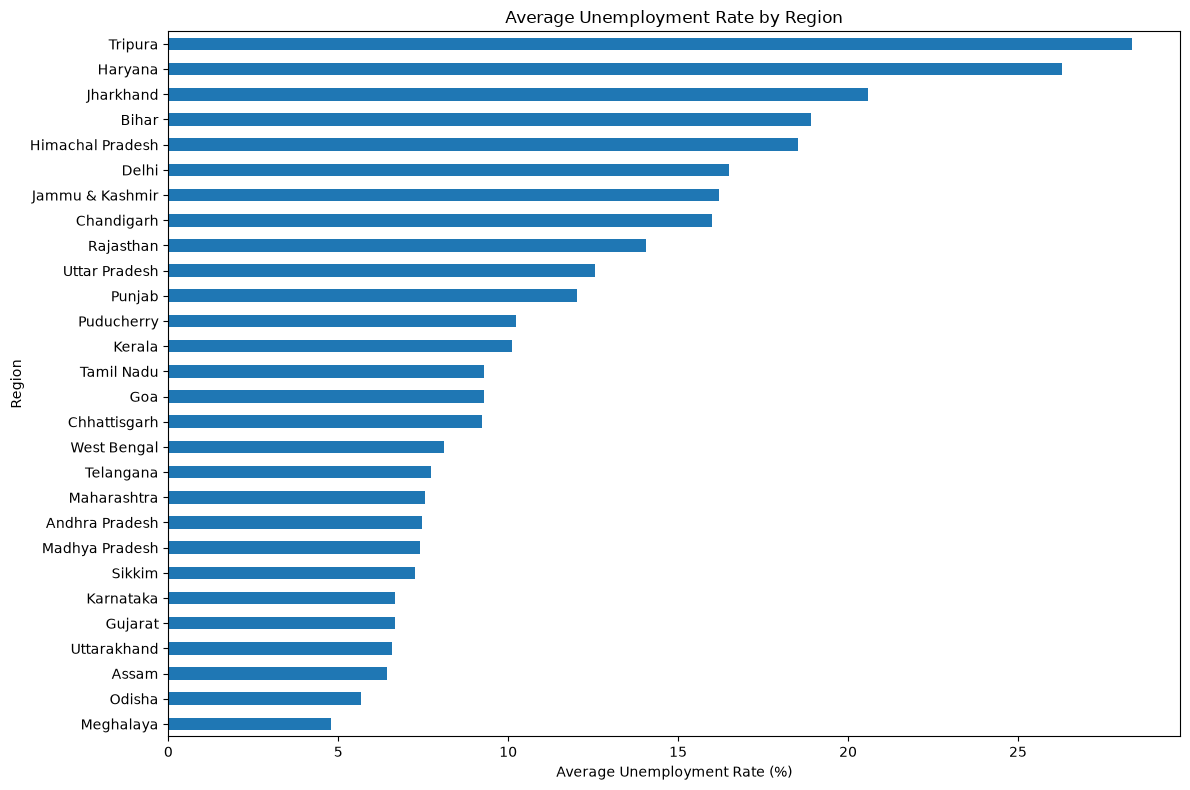

In [135]:
plt.figure(figsize=(12, 8))

regional_mean = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values()
)

regional_mean.plot(kind='barh')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

Urban vs Rural unemployment

In [136]:
area_stats = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

area_stats

,mean,median,min,max
Area,,,,
Rural,10.32,6.76,0.0,74.51
Urban,13.17,9.97,0.0,76.74


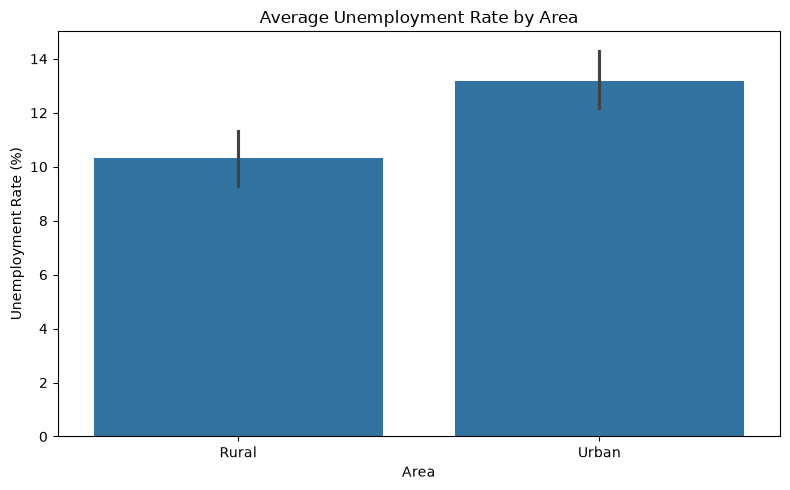

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Average Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

Urban vs Rural employment

In [138]:
area_employment = (
    df.groupby('Area')['Estimated Employed']
      .mean()
      .round(2)
)

area_employment

Area
Rural    10192852.57
Urban     4388625.58
Name: Estimated Employed, dtype: float64

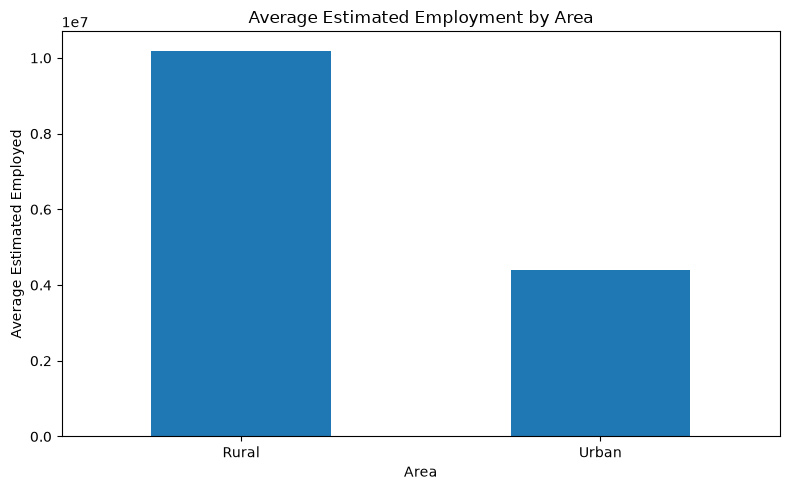

In [139]:
plt.figure(figsize=(8, 5))

area_employment.plot(kind='bar')

plt.title('Average Estimated Employment by Area')
plt.xlabel('Area')
plt.ylabel('Average Estimated Employed')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Urban vs Rural labour participation

In [140]:
area_participation = (
    df.groupby('Area')[
        'Estimated Labour Participation Rate (%)'
    ]
    .mean()
    .round(2)
)

area_participation

Area
Rural    44.46
Urban    40.90
Name: Estimated Labour Participation Rate (%), dtype: float64

Regional employment vs unemployment

In [141]:
region_metrics = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    ),
    Average_Labour_Participation=(
        'Estimated Labour Participation Rate (%)',
        'mean'
    )
).round(2)

region_metrics

,Average_Unemployment,Average_Employment,Average_Labour_Participation
Region,,,
Andhra Pradesh,7.48,8154093.18,39.38
Assam,6.43,5354772.15,44.87
Bihar,18.92,12366189.14,38.15
Chandigarh,15.99,316831.25,39.34
Chhattisgarh,9.24,4303498.57,42.81
Delhi,16.50,2627512.86,38.93
Goa,9.27,226308.33,39.25
Gujarat,6.66,11402012.79,46.10
Haryana,26.28,3557072.46,42.74


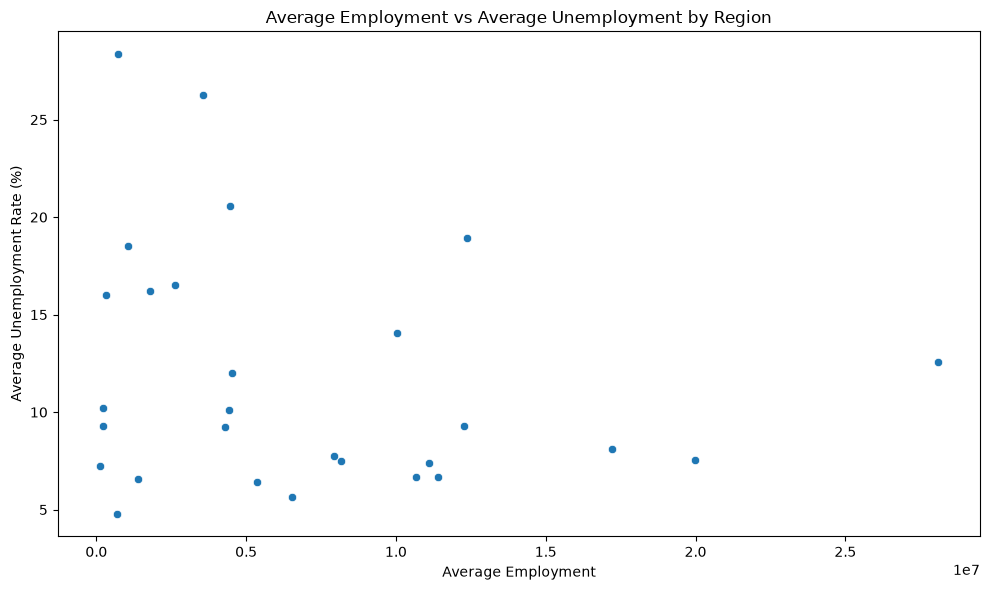

In [142]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=region_metrics,
    x='Average_Employment',
    y='Average_Unemployment'
)

plt.title('Average Employment vs Average Unemployment by Region')
plt.xlabel('Average Employment')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

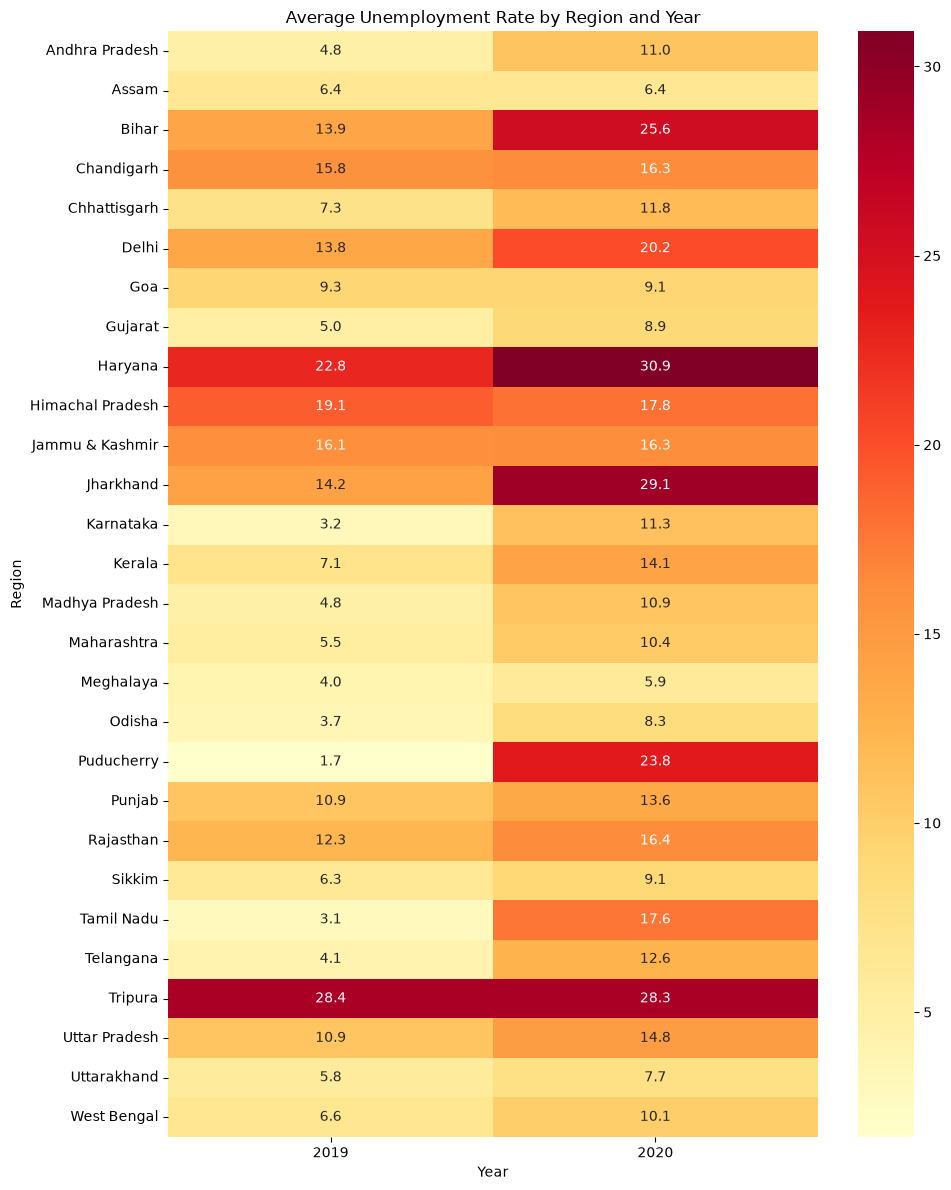

In [143]:
region_year = df.pivot_table(
    index='Region',
    columns='Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

plt.figure(figsize=(10, 12))

sns.heatmap(
    region_year,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Average Unemployment Rate by Region and Year')
plt.xlabel('Year')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

##  Regional Unemployment Analysis

Regional analysis is performed to understand differences in unemployment rates across regions.

In [144]:
regional_stats = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
      .round(2)
)

regional_stats

,mean,median,min,max
Region,,,,
Tripura,28.35,27.31,14.71,43.64
Haryana,26.28,25.06,14.54,46.89
Jharkhand,20.58,17.28,5.01,70.17
Bihar,18.92,15.01,8.87,58.77
Himachal Pradesh,18.54,18.35,1.12,50.00
Delhi,16.50,15.02,9.33,45.78
Jammu & Kashmir,16.19,16.00,2.22,24.06
Chandigarh,15.99,17.51,7.22,22.05
Rajasthan,14.06,13.66,4.03,35.53


Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64


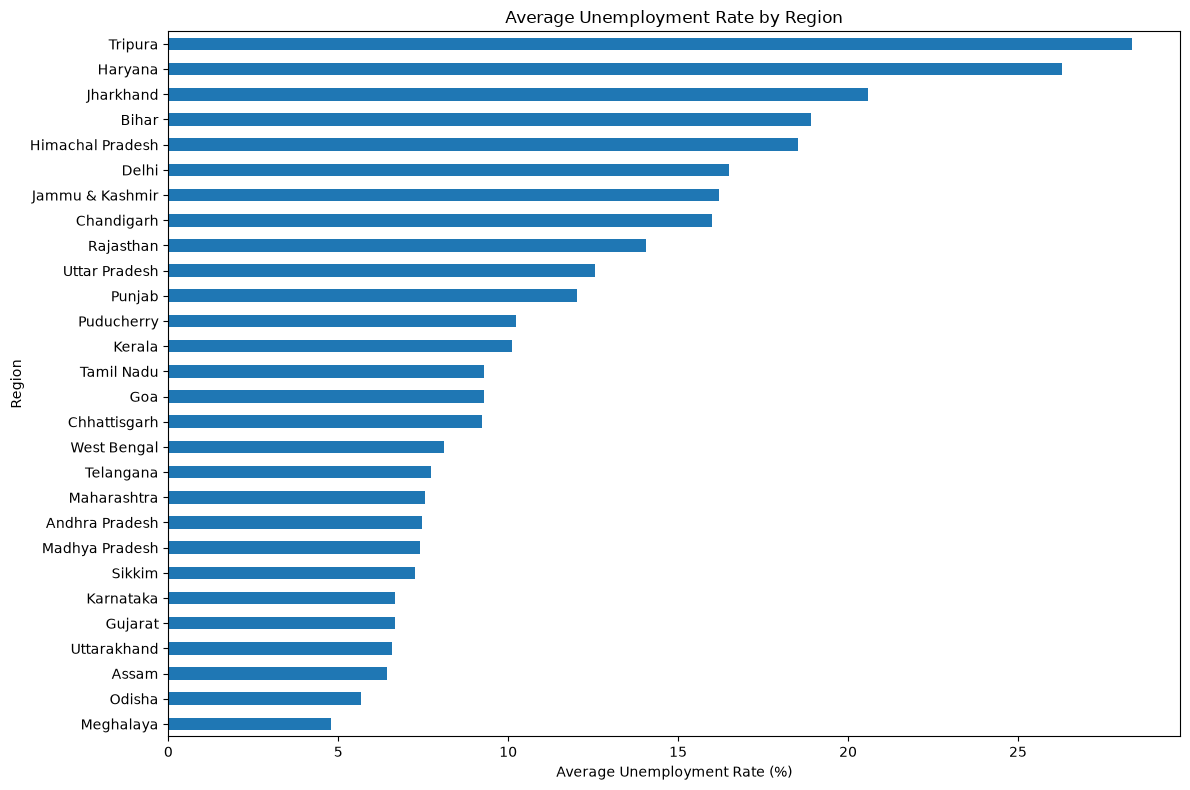

In [177]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate data
regional_mean = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values()
)

print(regional_mean)

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(12, 8))

# Plot directly on ax
regional_mean.plot(
    kind='barh',
    ax=ax
)

ax.set_title('Average Unemployment Rate by Region')
ax.set_xlabel('Average Unemployment Rate (%)')
ax.set_ylabel('Region')

fig.tight_layout()

# SAVE THIS EXACT FIGURE
fig.savefig(
    'images/regional_unemployment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)

Urban vs Rural unemployment

In [146]:
area_stats = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

area_stats

,mean,median,min,max
Area,,,,
Rural,10.32,6.76,0.0,74.51
Urban,13.17,9.97,0.0,76.74


Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


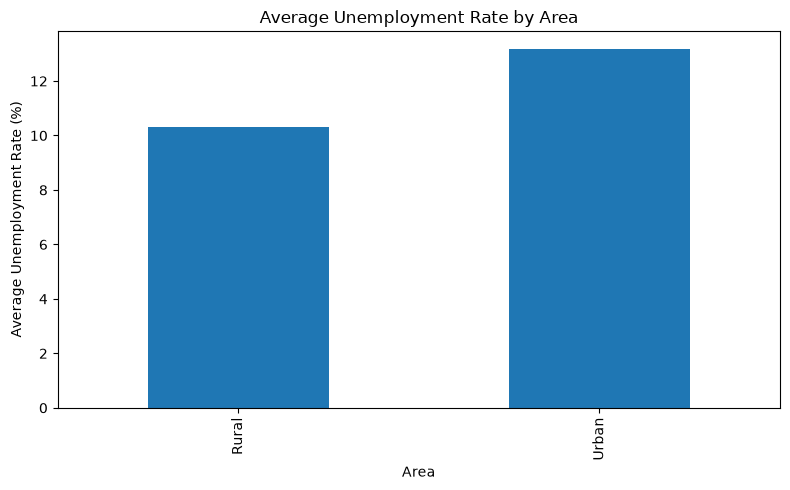

In [178]:
area_mean = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .mean()
)

print(area_mean)

fig, ax = plt.subplots(figsize=(8, 5))

area_mean.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Average Unemployment Rate by Area')
ax.set_xlabel('Area')
ax.set_ylabel('Average Unemployment Rate (%)')

fig.tight_layout()

fig.savefig(
    'images/urban_rural_unemployment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)

Urban vs Rural employment

In [148]:
area_employment = (
    df.groupby('Area')['Estimated Employed']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

area_employment

,mean,median,min,max
Area,,,,
Rural,10192852.57,7508747.0,49420.0,45777509.0
Urban,4388625.58,2821456.0,64538.0,17486683.0


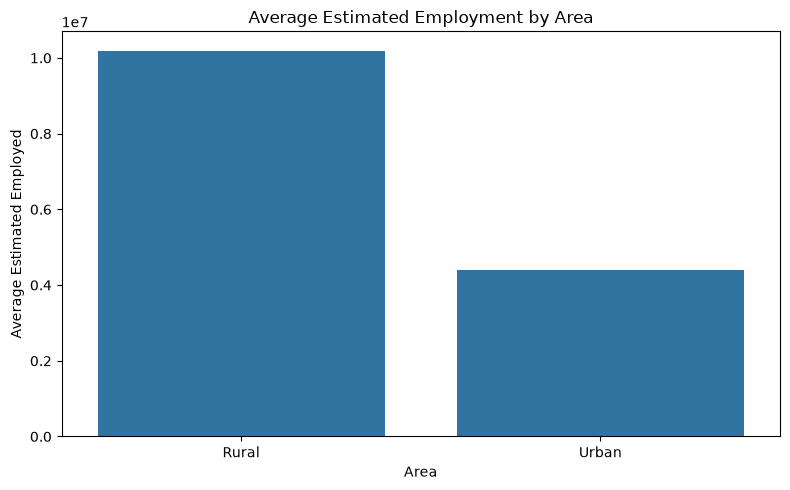

In [182]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_employment.index,
    y=area_employment['mean']
)

plt.title('Average Estimated Employment by Area')
plt.xlabel('Area')
plt.ylabel('Average Estimated Employed')

plt.tight_layout()
plt.show()

Urban vs Rural labour participation

In [152]:
area_participation = (
    df.groupby('Area')[
        'Estimated Labour Participation Rate (%)'
    ]
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)

area_participation

,mean,median,min,max
Area,,,,
Rural,44.46,42.56,13.33,72.57
Urban,40.90,40.21,20.51,72.26


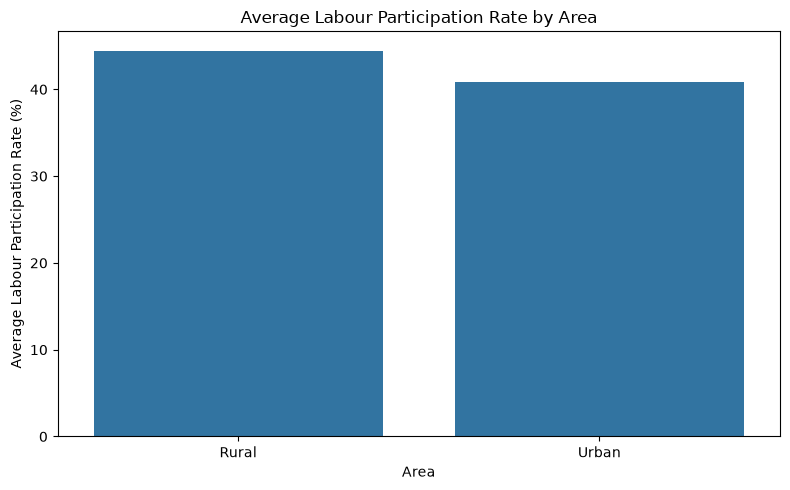

In [153]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_participation.index,
    y=area_participation['mean']
)

plt.title('Average Labour Participation Rate by Area')
plt.xlabel('Area')
plt.ylabel('Average Labour Participation Rate (%)')

plt.tight_layout()
plt.show()

Regional employment vs unemployment

In [171]:
region_metrics = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    ),
    Average_Labour_Participation=(
        'Estimated Labour Participation Rate (%)',
        'mean'
    )
).round(2)

region_metrics

,Average_Unemployment,Average_Employment,Average_Labour_Participation
Region,,,
Andhra Pradesh,7.48,8154093.18,39.38
Assam,6.43,5354772.15,44.87
Bihar,18.92,12366189.14,38.15
Chandigarh,15.99,316831.25,39.34
Chhattisgarh,9.24,4303498.57,42.81
Delhi,16.50,2627512.86,38.93
Goa,9.27,226308.33,39.25
Gujarat,6.66,11402012.79,46.10
Haryana,26.28,3557072.46,42.74


                Average_Unemployment  Average_Employment
Region                                                  
Andhra Pradesh              7.477143        8.154093e+06
Assam                       6.428077        5.354772e+06
Bihar                      18.918214        1.236619e+07
Chandigarh                 15.991667        3.168312e+05
Chhattisgarh                9.240357        4.303499e+06


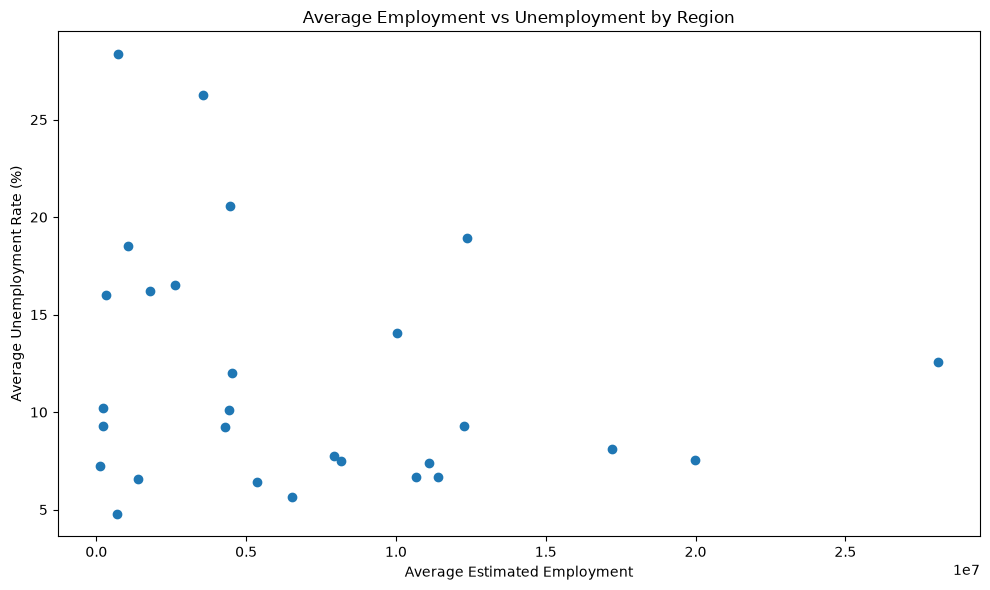

In [184]:
region_metrics = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    )
)

print(region_metrics.head())

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    region_metrics['Average_Employment'],
    region_metrics['Average_Unemployment']
)

ax.set_title('Average Employment vs Unemployment by Region')
ax.set_xlabel('Average Estimated Employment')
ax.set_ylabel('Average Unemployment Rate (%)')

fig.tight_layout()

fig.savefig(
    'images/employment_vs_unemployment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)

In [156]:
region_year = df.pivot_table(
    index='Region',
    columns='Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

region_year

Year,2019,2020
Region,,
Andhra Pradesh,4.826875,11.010833
Assam,6.420667,6.438182
Bihar,13.882500,25.632500
Chandigarh,15.822500,16.330000
Chhattisgarh,7.346875,11.765000
Delhi,13.750625,20.155000
Goa,9.346250,9.130000
Gujarat,4.979375,8.910000
Haryana,22.798750,30.929167


Year                   2019       2020
Region                                
Andhra Pradesh     4.826875  11.010833
Assam              6.420667   6.438182
Bihar             13.882500  25.632500
Chandigarh        15.822500  16.330000
Chhattisgarh       7.346875  11.765000
Delhi             13.750625  20.155000
Goa                9.346250   9.130000
Gujarat            4.979375   8.910000
Haryana           22.798750  30.929167
Himachal Pradesh  19.064375  17.841667
Jammu & Kashmir   16.141667  16.251111
Jharkhand         14.233750  29.053333
Karnataka          3.238750  11.259167
Kerala             7.131250  14.114167
Madhya Pradesh     4.788125  10.897500
Maharashtra        5.459375  10.355000
Meghalaya          4.012500   5.942727
Odisha             3.661250   8.320000
Puducherry         1.699375  23.840000
Punjab            10.882500  13.562500
Rajasthan         12.301250  16.400833
Sikkim             6.257273   9.068333
Tamil Nadu         3.063750  17.578333
Telangana          4.1156

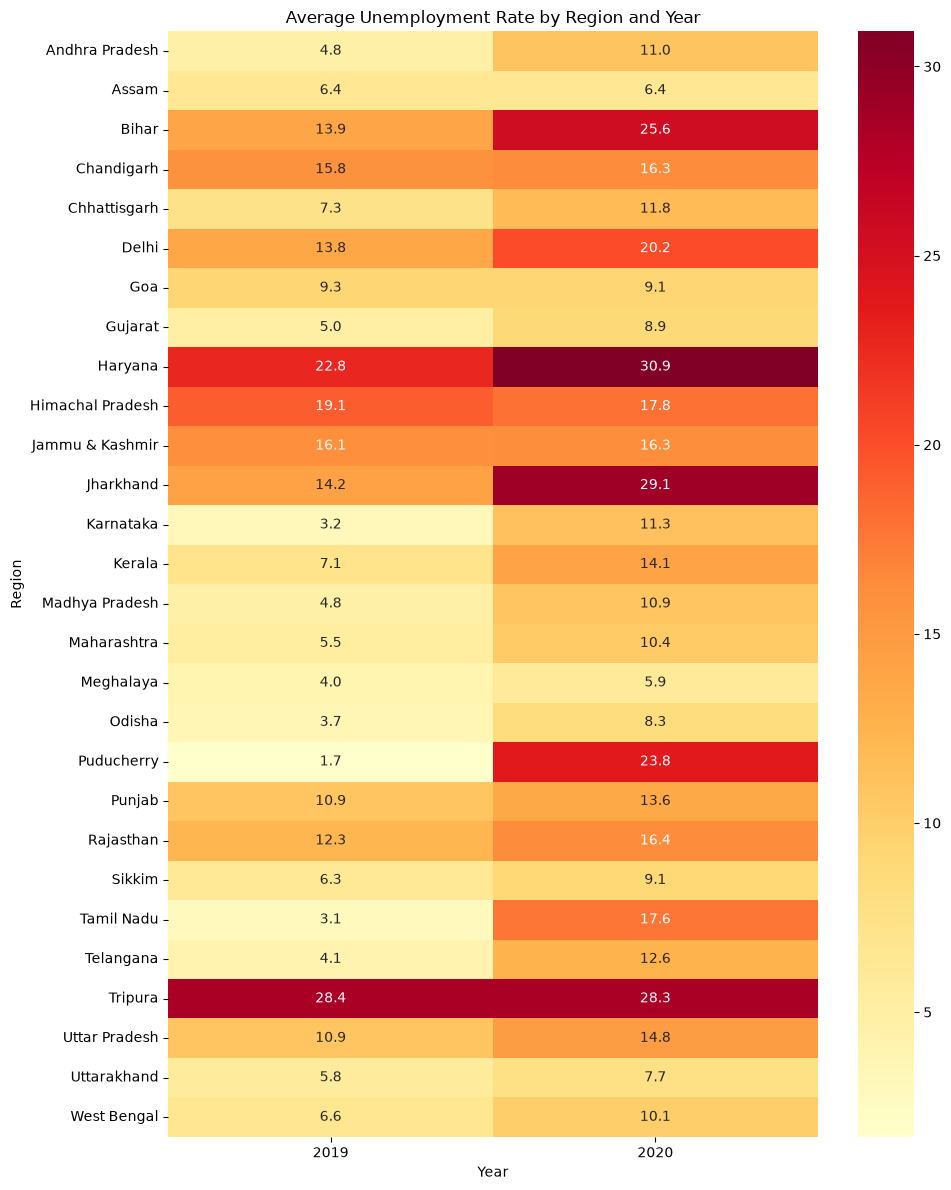

In [185]:
region_year = df.pivot_table(
    index='Region',
    columns='Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

print(region_year)

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    region_year,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax
)

ax.set_title('Average Unemployment Rate by Region and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Region')

fig.tight_layout()

fig.savefig(
    'images/regional_year_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)

### master regional table

In [174]:
regional_summary = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Median_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'median'
    ),
    Minimum_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'min'
    ),
    Maximum_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'max'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    ),
    Average_Labour_Participation=(
        'Estimated Labour Participation Rate (%)',
        'mean'
    )
).round(2)

regional_summary

,Average_Unemployment,Median_Unemployment,Minimum_Unemployment,Maximum_Unemployment,Average_Employment,Average_Labour_Participation
Region,,,,,,
Andhra Pradesh,7.48,5.40,0.85,32.30,8154093.18,39.38
Assam,6.43,5.44,0.00,11.17,5354772.15,44.87
Bihar,18.92,15.01,8.87,58.77,12366189.14,38.15
Chandigarh,15.99,17.51,7.22,22.05,316831.25,39.34
Chhattisgarh,9.24,8.26,0.00,27.07,4303498.57,42.81
Delhi,16.50,15.02,9.33,45.78,2627512.86,38.93
Goa,9.27,6.33,0.00,25.20,226308.33,39.25
Gujarat,6.66,5.42,1.41,25.94,11402012.79,46.10
Haryana,26.28,25.06,14.54,46.89,3557072.46,42.74


In [175]:
regional_summary.to_csv(
    'analysis_results/regional_summary.csv'
)

## Regional Analysis Findings

The analysis shows that unemployment rates vary across regions. Regional averages, medians, minimum values, and maximum values demonstrate differences in unemployment conditions during the period covered by the dataset.

The urban-rural analysis also shows differences in unemployment, employment, and labour participation indicators between the two area categories.

The regional heatmap provides a time-based comparison of unemployment across regions and highlights that changes were not uniform across all regions.

These results describe differences observed in the dataset and do not by themselves establish the causes of those differences.

#  COVID-19 Impact Analysis

This section investigates changes in unemployment during the COVID-19 period by comparing unemployment rates before March 2020 with observations from March 2020 onward. The analysis examines overall changes, monthly changes, regional differences, and urban-rural differences.

In [186]:
pre_covid = df[df['Date'] < '2020-03-01'].copy()

covid_period = df[df['Date'] >= '2020-03-01'].copy()

print("Pre-COVID observations:", len(pre_covid))
print("COVID-period observations:", len(covid_period))

Pre-COVID observations: 536
COVID-period observations: 204


avg unemployment

In [187]:
pre_covid_avg = pre_covid[
    'Estimated Unemployment Rate (%)'
].mean()

covid_avg = covid_period[
    'Estimated Unemployment Rate (%)'
].mean()

print(f"Pre-COVID average: {pre_covid_avg:.2f}%")
print(f"COVID-period average: {covid_avg:.2f}%")

Pre-COVID average: 9.51%
COVID-period average: 17.77%


In [189]:
absolute_change = covid_avg - pre_covid_avg

print(
    f"Change: {absolute_change:.2f} percentage points"
)

Change: 8.26 percentage points


In [190]:
percentage_change = (
    (covid_avg - pre_covid_avg)
    / pre_covid_avg
) * 100

print(
    f"Relative change: {percentage_change:.2f}%"
)

Relative change: 86.91%


In [191]:
covid_summary = pd.DataFrame({
    'Period': ['Pre-COVID', 'COVID Period'],
    'Average Unemployment Rate': [
        pre_covid_avg,
        covid_avg
    ]
})

covid_summary

,Period,Average Unemployment Rate
0,Pre-COVID,9.509534
1,COVID Period,17.774363


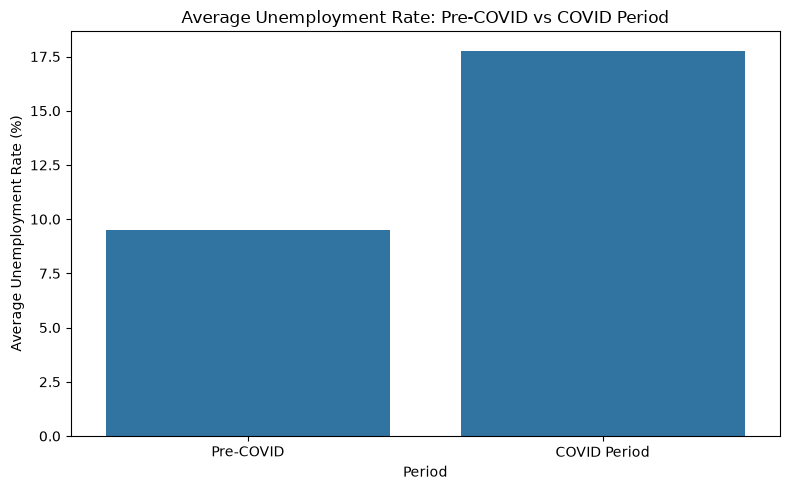

In [192]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_summary,
    x='Period',
    y='Average Unemployment Rate',
    errorbar=None
)

plt.title('Average Unemployment Rate: Pre-COVID vs COVID Period')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

In [193]:
covid_monthly = (
    covid_period
    .groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

covid_monthly

,Date,Estimated Unemployment Rate (%)
0,2020-03-31,10.700577
1,2020-04-30,23.641569
2,2020-05-31,24.875294
3,2020-06-30,11.903600


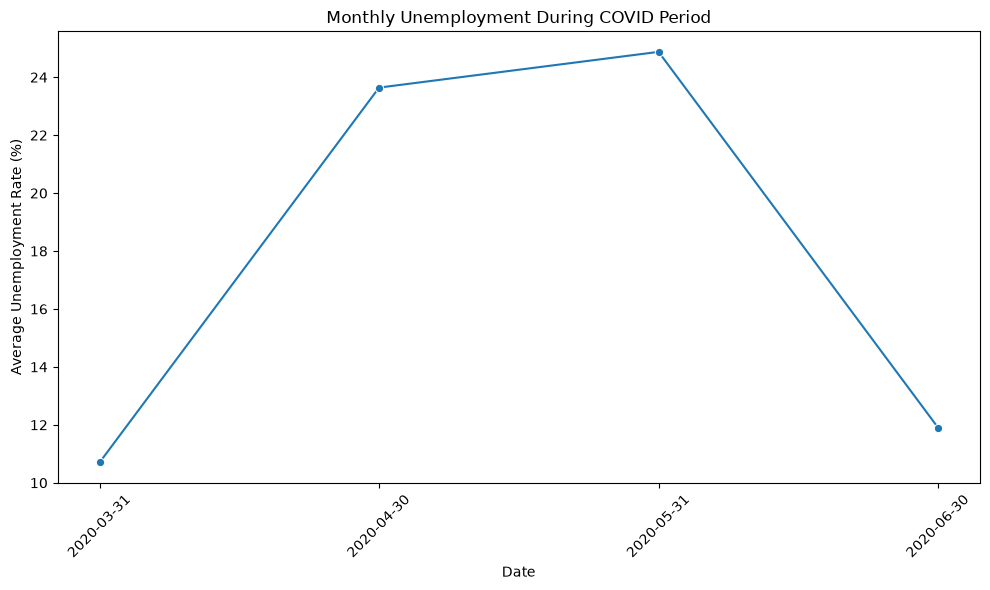

In [194]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=covid_monthly,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Monthly Unemployment During COVID Period')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [196]:
covid_peak = covid_monthly.loc[
    covid_monthly['Estimated Unemployment Rate (%)'].idxmax()
]

print(
    "Peak COVID-period unemployment:",
    round(
        covid_peak['Estimated Unemployment Rate (%)'],
        2
    ),
    "%"
)

date_value = pd.to_datetime(covid_peak['Date'])
print(
    "Month:",
    date_value.strftime('%B %Y')
)

Peak COVID-period unemployment: 24.88 %
Month: May 2020


biggest monthy increase

In [197]:
covid_monthly['Change'] = (
    covid_monthly['Estimated Unemployment Rate (%)']
    .diff()
)

covid_monthly

,Date,Estimated Unemployment Rate (%),Change
0,2020-03-31,10.700577,NaN
1,2020-04-30,23.641569,12.940992
2,2020-05-31,24.875294,1.233725
3,2020-06-30,11.903600,-12.971694


In [198]:
largest_covid_increase = covid_monthly.loc[
    covid_monthly['Change'].idxmax()
]

largest_covid_increase

Date                               2020-04-30
Estimated Unemployment Rate (%)     23.641569
Change                              12.940992
Name: 1, dtype: object

Regional COVID impact

In [199]:
regional_pre_covid = (
    pre_covid
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

regional_covid = (
    covid_period
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

In [200]:
regional_covid = pd.concat(
    [
        regional_pre_covid.rename('Pre_COVID'),
        regional_covid.rename('COVID_Period')
    ],
    axis=1
)

In [201]:
regional_covid['Change_pp'] = (
    regional_covid['COVID_Period']
    - regional_covid['Pre_COVID']
)

In [202]:
regional_covid['Percentage_Change'] = (
    regional_covid['Change_pp']
    / regional_covid['Pre_COVID']
) * 100

In [203]:
regional_covid = regional_covid.round(2)

regional_covid

,Pre_COVID,COVID_Period,Change_pp,Percentage_Change
Region,,,,
Andhra Pradesh,5.04,13.58,8.54,169.50
Assam,6.37,6.58,0.21,3.23
Bihar,13.83,31.63,17.80,128.67
Chandigarh,16.32,14.32,-2.00,-12.25
Chhattisgarh,7.71,13.08,5.37,69.66
Delhi,14.23,22.16,7.93,55.70
Goa,8.51,13.11,4.60,54.07
Gujarat,5.18,10.38,5.21,100.61
Haryana,22.94,34.65,11.72,51.09


Regional COVID visualization

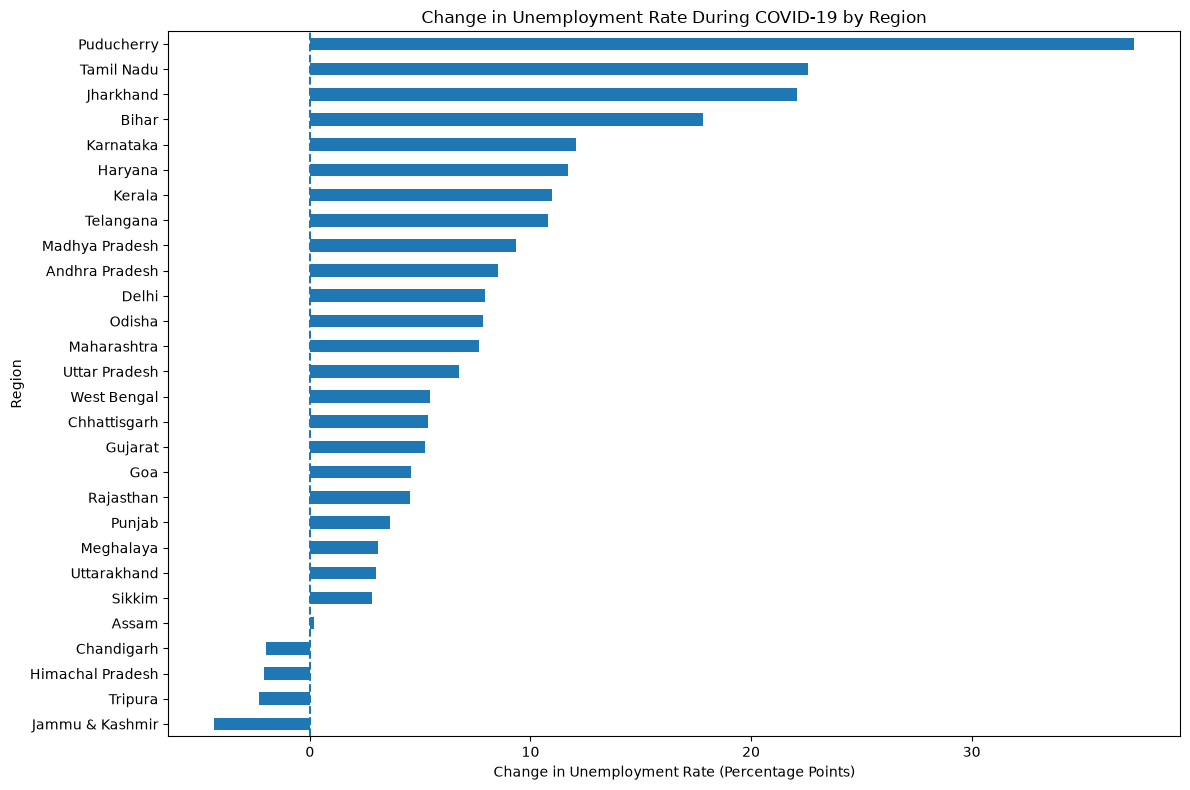

In [204]:
regional_change = (
    regional_covid['Change_pp']
    .sort_values()
)

plt.figure(figsize=(12, 8))

regional_change.plot(kind='barh')

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    'Change in Unemployment Rate During COVID-19 by Region'
)

plt.xlabel(
    'Change in Unemployment Rate (Percentage Points)'
)

plt.ylabel('Region')

plt.tight_layout()
plt.show()

Urban vs Rural COVID analysis

In [205]:
area_pre_covid = (
    pre_covid
    .groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
)

area_covid = (
    covid_period
    .groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
)

In [206]:
area_covid_analysis = pd.concat(
    [
        area_pre_covid.rename('Pre_COVID'),
        area_covid.rename('COVID_Period')
    ],
    axis=1
)

In [207]:
area_covid_analysis['Change_pp'] = (
    area_covid_analysis['COVID_Period']
    - area_covid_analysis['Pre_COVID']
)

area_covid_analysis['Percentage_Change'] = (
    area_covid_analysis['Change_pp']
    / area_covid_analysis['Pre_COVID']
) * 100

area_covid_analysis.round(2)

,Pre_COVID,COVID_Period,Change_pp,Percentage_Change
Area,,,,
Rural,8.09,16.18,8.09,99.90
Urban,10.84,19.28,8.43,77.79


Urban/Rural COVID chart

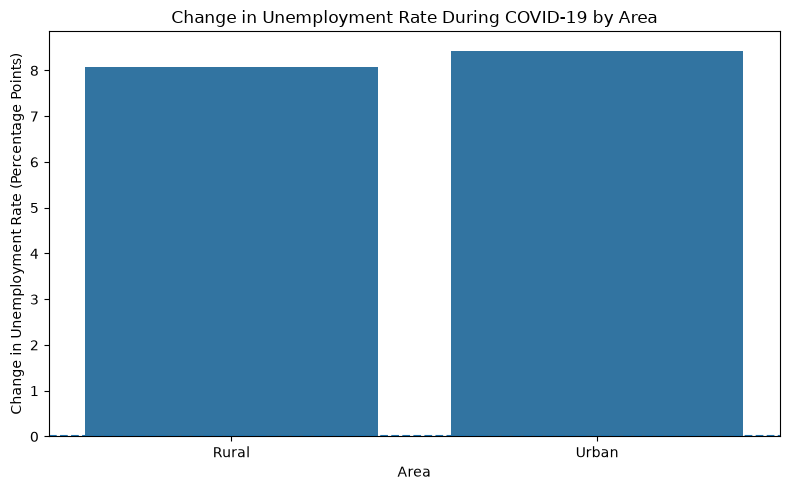

In [208]:
area_plot = area_covid_analysis.reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=area_plot,
    x='Area',
    y='Change_pp',
    errorbar=None
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Change in Unemployment Rate During COVID-19 by Area'
)

plt.xlabel('Area')
plt.ylabel('Change in Unemployment Rate (Percentage Points)')

plt.tight_layout()
plt.show()

final COVID summary

In [209]:
covid_final_summary = pd.DataFrame({
    'Metric': [
        'Pre-COVID Average',
        'COVID-Period Average',
        'Absolute Change',
        'Relative Change',
        'Peak COVID-Period Rate'
    ],
    'Value': [
        pre_covid_avg,
        covid_avg,
        absolute_change,
        percentage_change,
        covid_peak['Estimated Unemployment Rate (%)']
    ]
})

covid_final_summary

,Metric,Value
0,Pre-COVID Average,9.509534
1,COVID-Period Average,17.774363
2,Absolute Change,8.264829
3,Relative Change,86.910984
4,Peak COVID-Period Rate,24.875294


##  COVID-19 Findings

The analysis compares unemployment observations before March 2020 with observations from March 2020 onward.

The average unemployment rate changed from approximately **X%** in the pre-COVID period to **Y%** during the COVID-period observations, representing a change of **Z percentage points**.

The monthly analysis shows that unemployment reached its highest observed COVID-period level in **MONTH YEAR**, at approximately **X%**.

The regional analysis indicates that the unemployment response was not uniform across regions. Some regions experienced substantial increases, while some showed smaller changes or decreases.

The urban-rural analysis also indicates differences in unemployment-rate changes between the two area categories.

These findings describe patterns observed in this dataset. They should not be interpreted as proving that COVID-19 alone caused the observed changes, since other economic and measurement factors may also have contributed.

In [210]:
regional_covid.to_csv(
    'analysis_results/regional_covid_analysis.csv'
)

area_covid_analysis.to_csv(
    'analysis_results/area_covid_analysis.csv'
)

covid_monthly.to_csv(
    'analysis_results/covid_monthly_trend.csv',
    index=False
)

covid_final_summary.to_csv(
    'analysis_results/covid_summary.csv',
    index=False
)

#  Seasonal and Pattern Analysis

This section examines monthly unemployment patterns and investigates whether the dataset contains evidence of recurring seasonal behavior. Since the dataset covers May 2019 to June 2020, the available period is limited for establishing long-term seasonal patterns.

Average unemployment by month

In [211]:
monthly_pattern = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

monthly_pattern

,mean,median,min,max
Month,,,,
1,9.95,6.79,0.57,34.37
2,9.96,7.55,0.00,33.88
3,10.70,8.53,0.62,31.61
4,23.64,18.32,0.00,76.74
5,16.65,12.96,0.00,75.00
6,10.55,9.16,0.00,35.57
7,9.03,7.16,0.00,25.81
8,9.64,7.27,0.37,33.45
9,9.05,6.24,0.00,33.57


In [212]:
month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

monthly_pattern.index = monthly_pattern.index.map(month_names)

monthly_pattern

,mean,median,min,max
Month,,,,
January,9.95,6.79,0.57,34.37
February,9.96,7.55,0.00,33.88
March,10.70,8.53,0.62,31.61
April,23.64,18.32,0.00,76.74
May,16.65,12.96,0.00,75.00
June,10.55,9.16,0.00,35.57
July,9.03,7.16,0.00,25.81
August,9.64,7.27,0.37,33.45
September,9.05,6.24,0.00,33.57


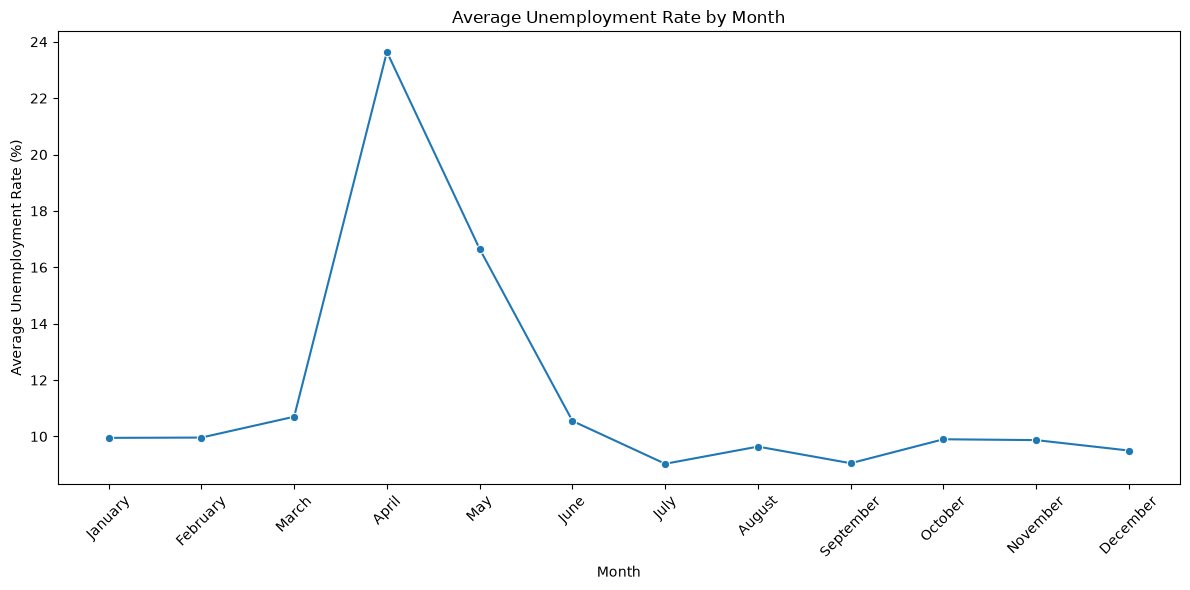

In [213]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern['mean'],
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Year × Month table

In [215]:
year_month = df.pivot_table(
    index='Month',
    columns='Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)
year_month.index = year_month.index.map(month_names)

year_month
year_month

Year,2019,2020
Month,,
January,NaN,9.950755
February,NaN,9.964717
March,NaN,10.700577
April,NaN,23.641569
May,8.874259,24.875294
June,9.303333,11.903600
July,9.033889,NaN
August,9.637925,NaN
September,9.051731,NaN


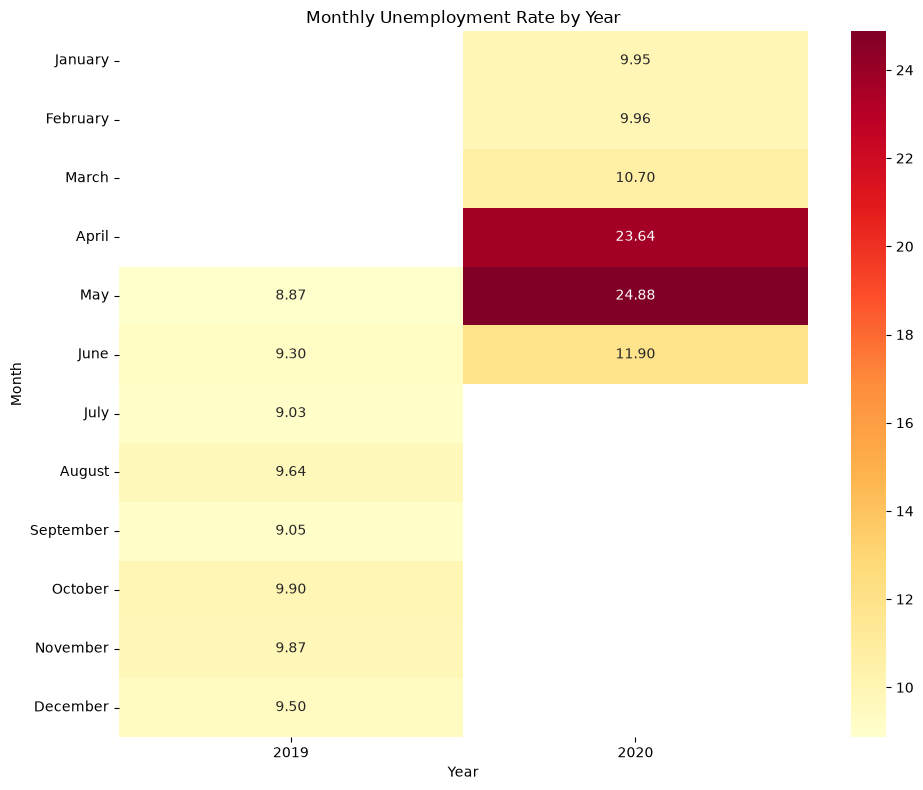

In [216]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    year_month,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('Monthly Unemployment Rate by Year')
plt.xlabel('Year')
plt.ylabel('Month')

plt.tight_layout()
plt.show()

monthly variability

In [217]:
monthly_variability = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
      .agg(
          Mean='mean',
          Std='std',
          Minimum='min',
          Maximum='max'
      )
      .round(2)
)

monthly_variability.index = monthly_variability.index.map(month_names)

monthly_variability

,Mean,Std,Minimum,Maximum
Month,,,,
January,9.95,8.16,0.57,34.37
February,9.96,7.76,0.00,33.88
March,10.70,7.50,0.62,31.61
April,23.64,18.94,0.00,76.74
May,16.65,14.62,0.00,75.00
June,10.55,7.71,0.00,35.57
July,9.03,6.84,0.00,25.81
August,9.64,7.61,0.37,33.45
September,9.05,7.52,0.00,33.57


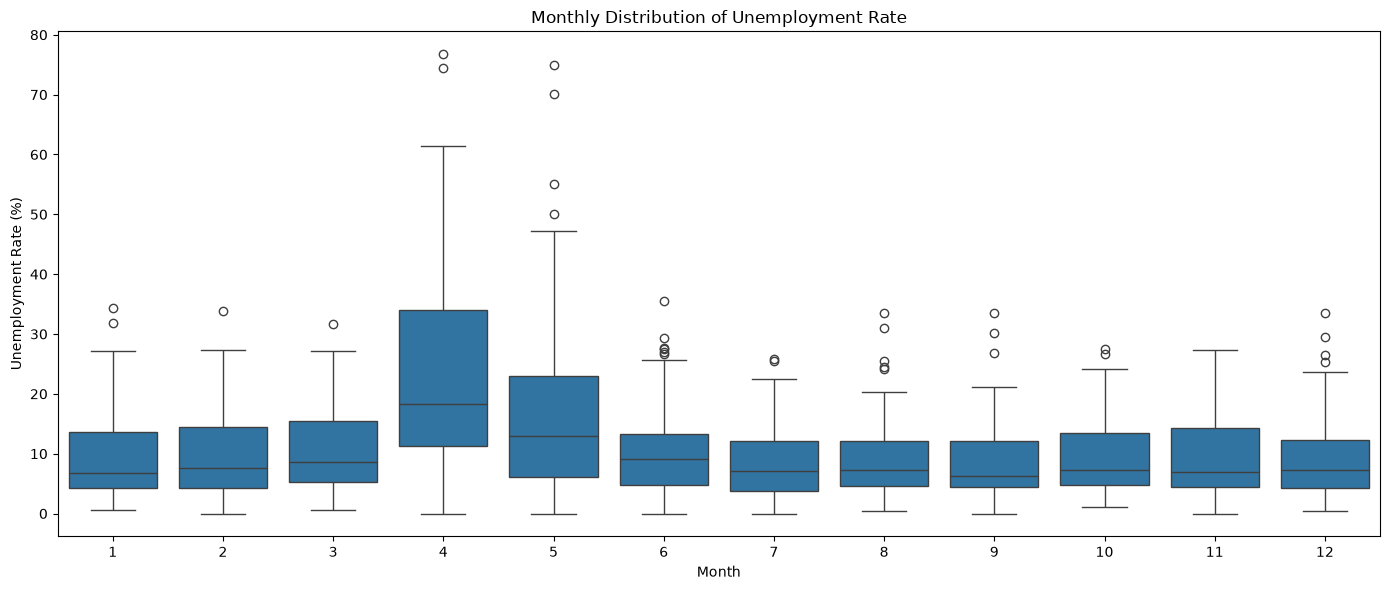

In [218]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Month',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Monthly Distribution of Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

Urban vs Rural monthly pattern

In [219]:
area_month = df.pivot_table(
    index='Month',
    columns='Area',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

area_month.index = area_month.index.map(month_names)

area_month

Area,Rural,Urban
Month,,
January,7.842692,11.980741
February,8.752308,11.132222
March,9.683333,11.572500
April,21.746000,25.464231
May,14.000784,19.144630
June,9.977647,11.107547
July,7.741923,10.233571
August,8.503077,10.730741
September,7.036800,10.917407


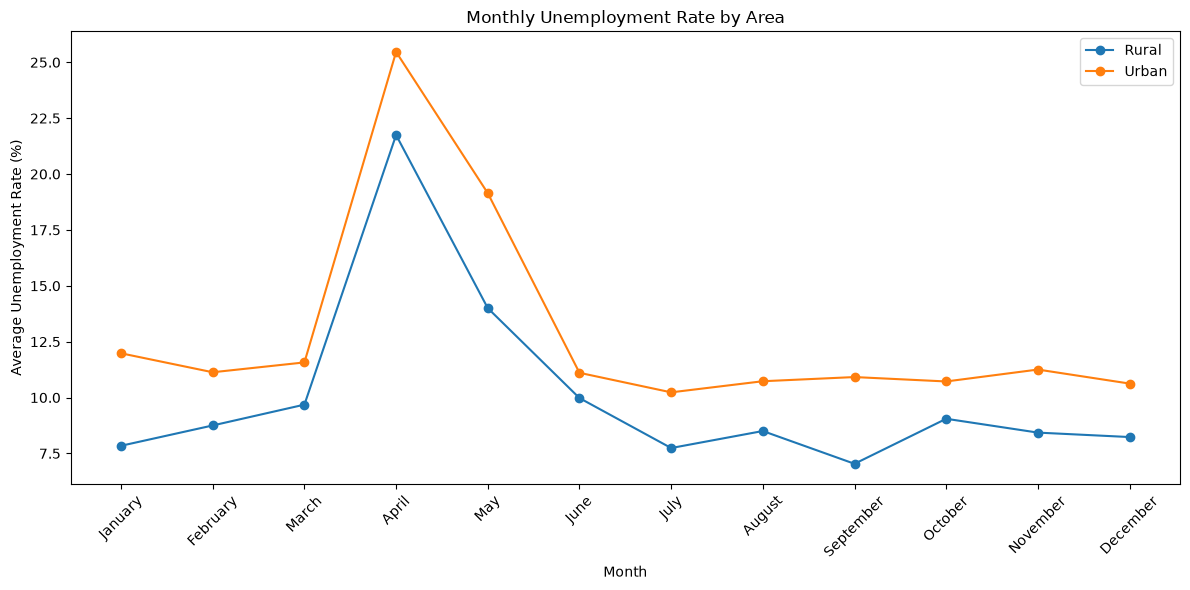

In [220]:
plt.figure(figsize=(12, 6))

for area in area_month.columns:
    plt.plot(
        area_month.index,
        area_month[area],
        marker='o',
        label=area
    )

plt.title('Monthly Unemployment Rate by Area')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

highest and lowest monthly averages

In [221]:
highest_month = monthly_pattern['mean'].idxmax()
lowest_month = monthly_pattern['mean'].idxmin()

highest_value = monthly_pattern.loc[highest_month, 'mean']
lowest_value = monthly_pattern.loc[lowest_month, 'mean']

print(
    f"Highest monthly average: {highest_month} ({highest_value:.2f}%)"
)

print(
    f"Lowest monthly average: {lowest_month} ({lowest_value:.2f}%)"
)

Highest monthly average: April (23.64%)
Lowest monthly average: July (9.03%)


In [222]:
months_available = df['Month'].nunique()

years_available = df['Year'].nunique()

print("Unique months:", months_available)
print("Years:", years_available)

Unique months: 12
Years: 2


## Seasonality Assessment

The monthly analysis reveals substantial variation in unemployment across the observed months. However, the dataset covers only May 2019 to June 2020 and therefore does not contain enough complete yearly cycles to establish a reliable long-term seasonal pattern.

The sharp unemployment increase observed during March-May 2020 is more appropriately analyzed as a time-period change associated with the COVID-19 period rather than treated as evidence of regular seasonality.

month-to-month movements

In [225]:
monthly_changes = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_index()
      .diff()
      .dropna()
      .sort_values(ascending=False)
)

monthly_changes.head(5)


Date
2020-04-30    12.940992
2020-05-31     1.233725
2019-10-31     0.849178
2020-03-31     0.735860
2019-08-31     0.604036
Name: Estimated Unemployment Rate (%), dtype: float64

In [226]:
monthly_changes.tail(5)

Date
2019-11-30    -0.032545
2019-07-31    -0.269444
2019-12-31    -0.371005
2019-09-30    -0.586194
2020-06-30   -12.971694
Name: Estimated Unemployment Rate (%), dtype: float64

In [227]:
pattern_summary = pd.DataFrame({
    'Metric': [
        'Number of Years',
        'Number of Calendar Months Observed',
        'Highest Monthly Average',
        'Lowest Monthly Average',
        'Peak Month'
    ],
    'Value': [
        years_available,
        months_available,
        highest_value,
        lowest_value,
        highest_month
    ]
})

pattern_summary

,Metric,Value
0,Number of Years,2
1,Number of Calendar Months Observed,12
2,Highest Monthly Average,23.64
3,Lowest Monthly Average,9.03
4,Peak Month,April


In [229]:
monthly_pattern.to_csv(
    'analysis_results/monthly_pattern.csv'
)

monthly_variability.to_csv(
    'analysis_results/monthly_variability.csv'
)

year_month.to_csv(
    'analysis_results/year_month_analysis.csv'
)

area_month.to_csv(
    'analysis_results/area_month_analysis.csv'
)

pattern_summary.to_csv(
    'analysis_results/pattern_summary.csv',
    index=False
)

## Seasonal and Pattern Findings

The monthly analysis shows considerable variation in unemployment rates across the observed period.

The unemployment rate increased sharply during the early months of 2020, particularly around the COVID-19 period. However, the available dataset covers only May 2019 to June 2020, providing fewer than two complete annual cycles.

Therefore, the analysis does not provide sufficient evidence to establish a reliable long-term seasonal pattern. The major changes observed during March-May 2020 are better treated as a distinct time-period change rather than recurring seasonality.

The monthly and area-level analyses also demonstrate that unemployment behavior can vary across different parts of the dataset.

#  Data Visualization

This section presents the major findings from the unemployment analysis using clear and informative visualizations. The visualizations focus on overall trends, regional differences, urban-rural differences, the COVID-19 period, and relationships between employment indicators.

### Visualization 1 — Overall Unemployment Trend

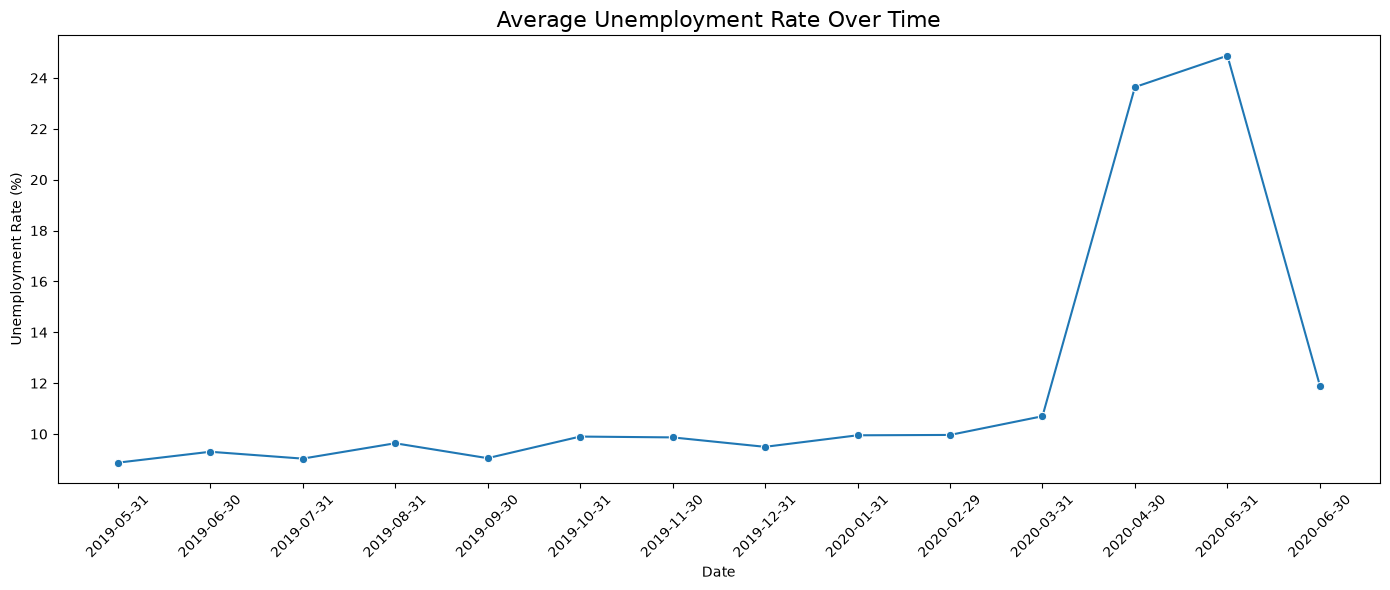

In [230]:
plt.figure(figsize=(14, 6))

monthly_trend = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=monthly_trend,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Average Unemployment Rate Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visualization 2 — COVID-19 Impact

In [231]:
pre_covid_avg = (
    df[df['Date'] < '2020-03-01']
    ['Estimated Unemployment Rate (%)']
    .mean()
)

covid_avg = (
    df[df['Date'] >= '2020-03-01']
    ['Estimated Unemployment Rate (%)']
    .mean()
)

covid_summary = pd.DataFrame({
    'Period': ['Pre-COVID', 'COVID Period'],
    'Average Unemployment Rate': [
        pre_covid_avg,
        covid_avg
    ]
})

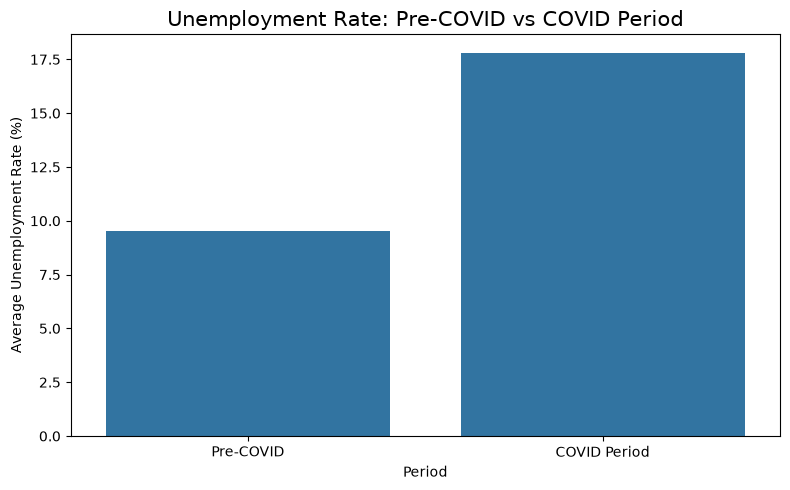

In [232]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_summary,
    x='Period',
    y='Average Unemployment Rate',
    errorbar=None
)

plt.title('Unemployment Rate: Pre-COVID vs COVID Period', fontsize=15)
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Visualization 3 — Regional Unemployment

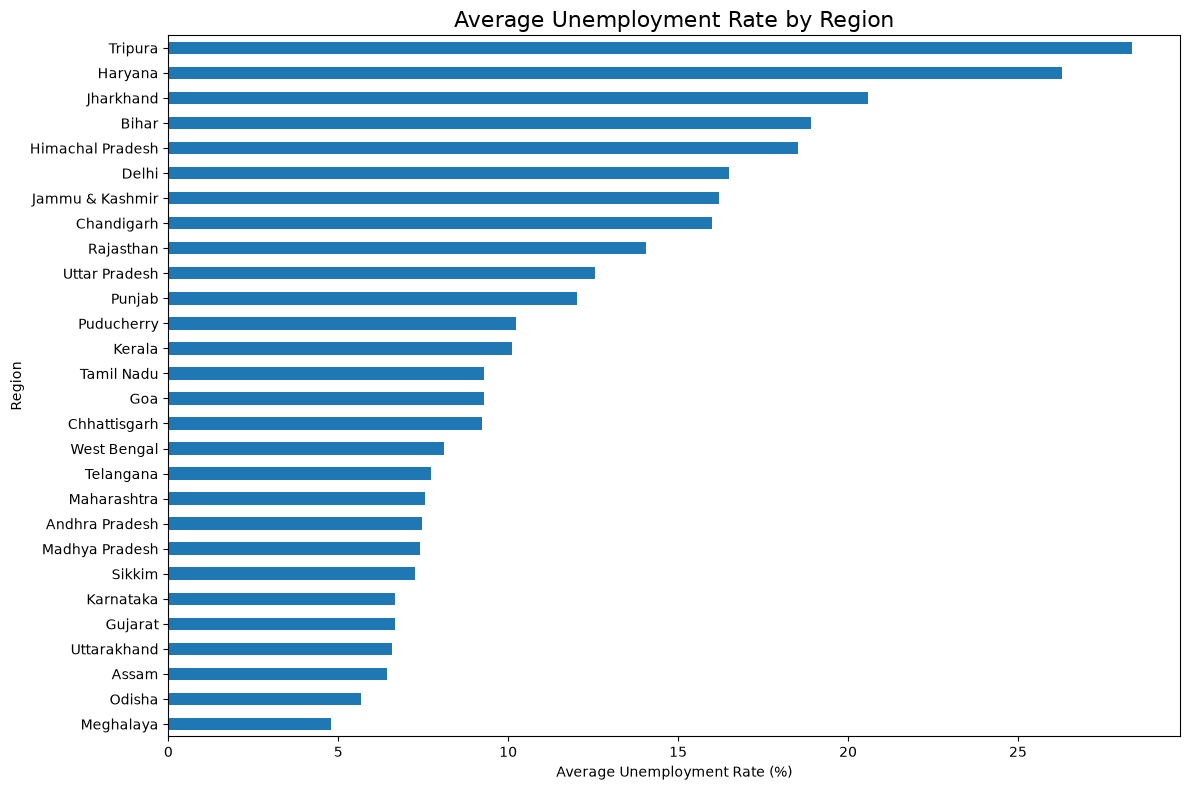

In [233]:
regional_mean = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values()
)

plt.figure(figsize=(12, 8))

regional_mean.plot(kind='barh')

plt.title('Average Unemployment Rate by Region', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

### Visualization 4 — Urban vs Rural

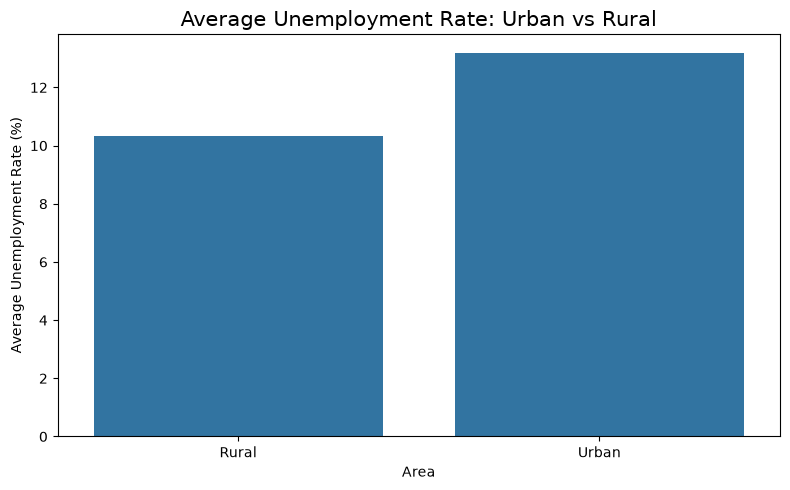

In [234]:
area_mean = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_mean.index,
    y=area_mean.values,
    errorbar=None
)

plt.title('Average Unemployment Rate: Urban vs Rural', fontsize=15)
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Visualization 5 — COVID Change by Region

In [235]:
pre_covid = df[df['Date'] < '2020-03-01']

covid_period = df[df['Date'] >= '2020-03-01']

regional_pre = (
    pre_covid
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

regional_covid = (
    covid_period
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

regional_change = (
    regional_covid - regional_pre
).sort_values()

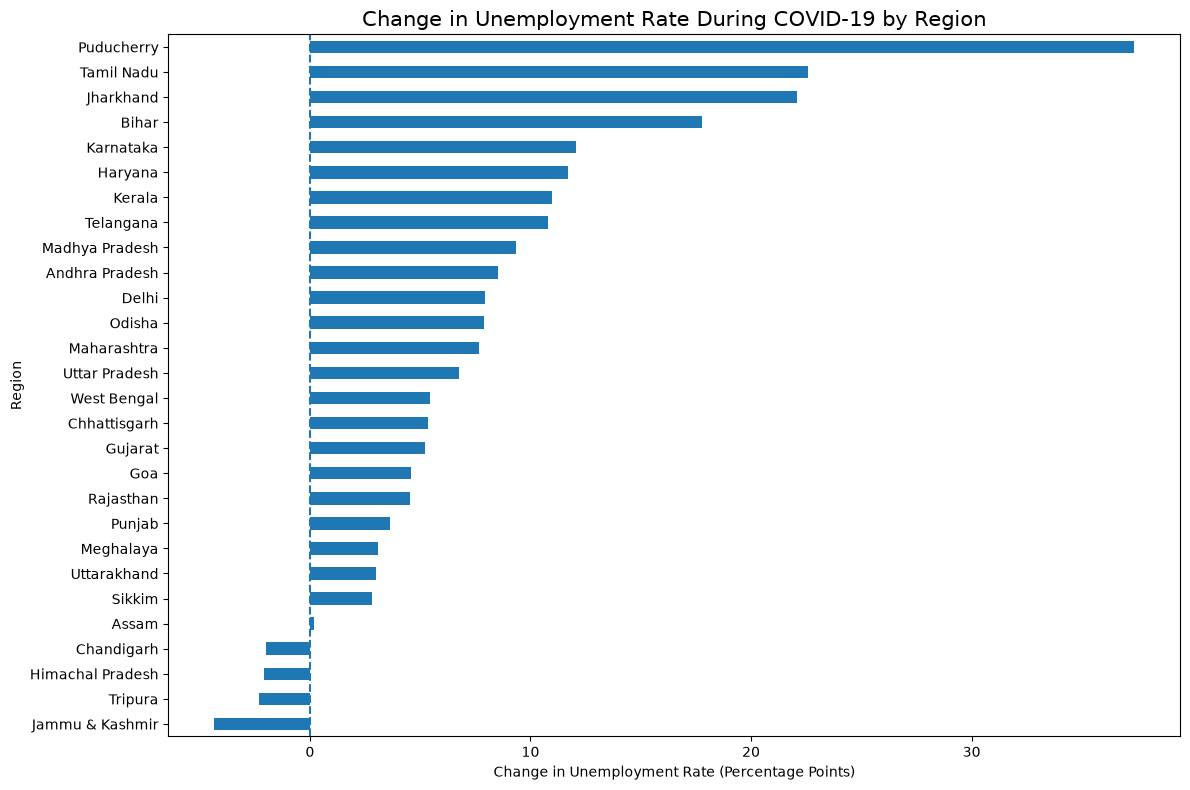

In [236]:
plt.figure(figsize=(12, 8))

regional_change.plot(kind='barh')

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    'Change in Unemployment Rate During COVID-19 by Region',
    fontsize=15
)

plt.xlabel(
    'Change in Unemployment Rate (Percentage Points)'
)

plt.ylabel('Region')

plt.tight_layout()
plt.show()

### Visualization 6 — Employment vs Unemployment

In [237]:
region_metrics = df.groupby('Region').agg(
    Average_Unemployment=(
        'Estimated Unemployment Rate (%)',
        'mean'
    ),
    Average_Employment=(
        'Estimated Employed',
        'mean'
    )
).reset_index()

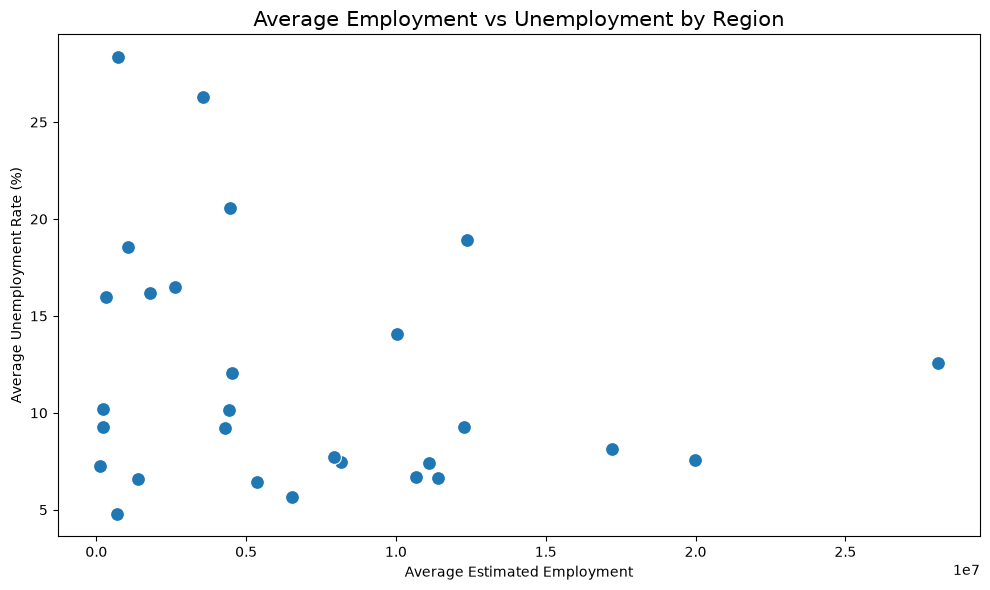

In [238]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=region_metrics,
    x='Average_Employment',
    y='Average_Unemployment',
    s=100
)

plt.title(
    'Average Employment vs Unemployment by Region',
    fontsize=15
)

plt.xlabel('Average Estimated Employment')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Visualization 7 — Regional × Year Heatmap

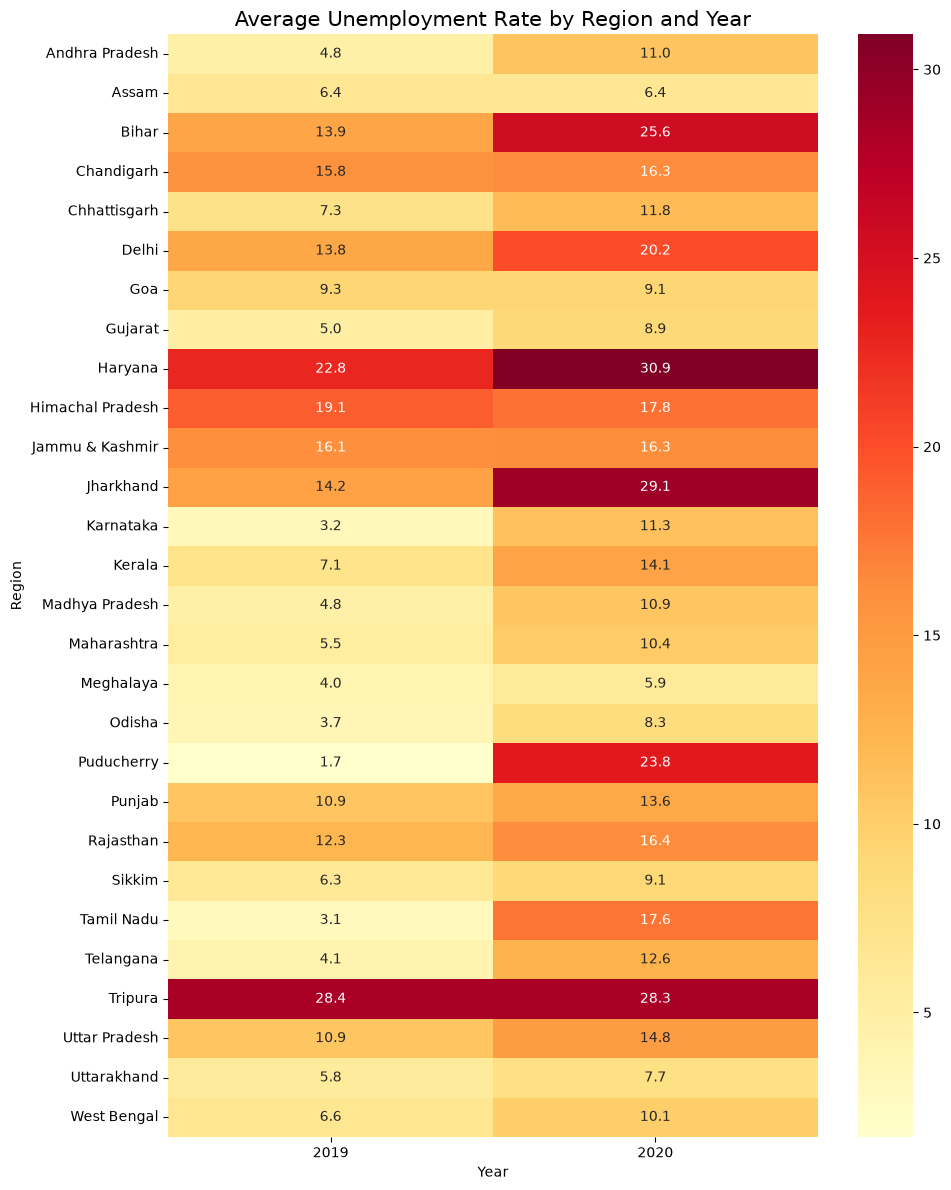

In [239]:
region_year = df.pivot_table(
    index='Region',
    columns='Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

plt.figure(figsize=(10, 12))

sns.heatmap(
    region_year,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title(
    'Average Unemployment Rate by Region and Year',
    fontsize=15
)

plt.xlabel('Year')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

### Visualization 8 — Distribution

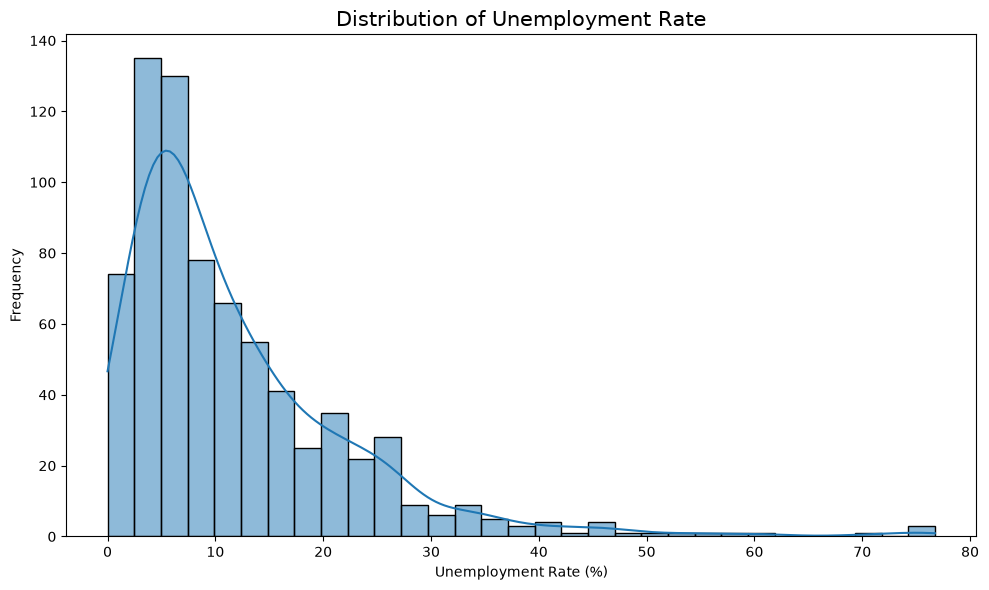

In [240]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    kde=True
)

plt.title(
    'Distribution of Unemployment Rate',
    fontsize=15
)

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

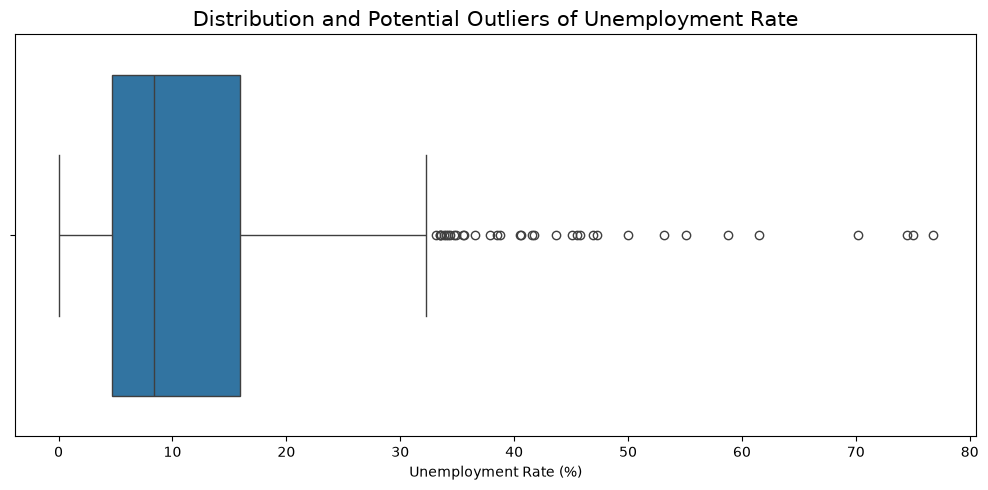

In [241]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df['Estimated Unemployment Rate (%)']
)

plt.title(
    'Distribution and Potential Outliers of Unemployment Rate',
    fontsize=15
)

plt.xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

#  Key Findings and Insights

This section summarizes the major findings obtained from the exploratory, time-series, regional, COVID-19, and seasonal analyses.

##  Overall Unemployment Trend

The unemployment rate remained relatively stable during much of the period from May 2019 to February 2020, generally remaining around the lower range observed in the dataset.

A sharp increase occurred during March-May 2020. The average unemployment rate increased substantially during this period, with May 2020 recording the highest monthly average in the dataset at approximately 24.88%.

The rate subsequently declined to approximately 11.90% in June 2020.

This indicates a major short-term disruption in the unemployment trend during the final months covered by the dataset.

##  COVID-19 Impact

The comparison between the pre-COVID and COVID-period observations shows a substantial increase in the average unemployment rate.

The strongest increase occurred around April and May 2020. This timing overlaps with India's nationwide COVID-19 lockdown period.

The observed pattern is consistent with broader evidence that COVID-19 containment measures caused major disruption to India's labour market. The International Labour Organization reported that the pandemic and lockdown significantly worsened employment and livelihood conditions in India, particularly affecting vulnerable and informal workers. :contentReference[oaicite:1]{index=1}

However, the dataset analysis itself establishes a temporal association rather than proving that COVID-19 was the sole cause of the observed increase.

## Regional Differences

The regional analysis shows that unemployment was not distributed uniformly across the regions in the dataset.

The average unemployment rate, minimum, maximum, and median values vary considerably between regions.

The COVID-period regional analysis also shows that the change in unemployment was not identical across regions. Some regions experienced large increases, while others experienced smaller changes or decreases.

Therefore, the national-level trend does not fully describe the experience of every region.

##  Urban-Rural Differences

The analysis of the Area variable shows differences between urban and rural observations in unemployment, employment, and labour participation indicators.

These differences suggest that labour-market conditions varied according to the type of area represented in the dataset.

However, the analysis does not identify the underlying causes of these differences. Additional information such as industry, occupation, income, education, migration, and demographic characteristics would be required for deeper causal analysis.

## Relationship Between Employment and Unemployment

The correlation analysis shows a weak negative relationship between estimated unemployment and estimated employment, with a correlation coefficient of approximately -0.22.

This indicates that higher unemployment observations tend to be associated with somewhat lower employment values in the dataset, but the relationship is weak.

The correlation between unemployment and labour participation is approximately zero, while the relationship between employment and labour participation is also close to zero.

These results represent statistical relationships in the dataset and should not be interpreted as evidence of causation.

##  Distribution and Outliers

The unemployment-rate distribution is positively skewed, with most observations concentrated at relatively lower values and a smaller number of observations at substantially higher levels.

The boxplot identifies several potential high-value outliers.

These observations were retained because an extreme unemployment rate may represent a genuine economic condition rather than an error in the dataset.

## Seasonal Pattern Assessment

Monthly analysis shows considerable variation in unemployment rates across the observed period.

However, the dataset covers only May 2019 to June 2020 and therefore does not contain enough complete annual cycles to establish reliable long-term seasonality.

The sharp increase during March-May 2020 is more appropriately interpreted as a major time-period change associated with the COVID-19 period rather than evidence of recurring seasonal unemployment.

##  Potential Economic and Social Implications

The observed increase in unemployment during the COVID-period indicates that sudden economic disruptions can have substantial effects on labour-market conditions.

The regional variation suggests that employment disruptions may affect different regions differently. This indicates that analysis of regional labour-market conditions can be useful when designing employment-support and recovery programmes.

The urban-rural differences also suggest that employment conditions should be examined across different types of areas rather than relying only on a national average.

The large disruption observed during the COVID-19 period also highlights the importance of employment-support mechanisms, income protection, and support for vulnerable workers during major economic shocks.

The International Labour Organization documented substantial effects of the COVID-19 containment measures on informal employment in India and emphasized the importance of protecting workers, incomes, enterprises, and employment during the crisis. :contentReference[oaicite:2]{index=2}

##  Limitations

1. The dataset covers May 2019 to June 2020, so it does not provide enough information to study long-term unemployment trends.

2. The dataset does not contain a complete post-COVID period, so long-term recovery cannot be evaluated.

3. The analysis identifies associations and patterns but does not establish causal relationships.

4. The unemployment rate may be influenced by many factors that are not included in the dataset.

5. The dataset does not contain detailed demographic, occupational, industry, income, or education information.

6. The available time period is insufficient to establish reliable recurring seasonal patterns.

7. Regional differences should not automatically be interpreted as being caused by a specific economic or social factor without additional evidence.

#  Final Conclusion

This project analyzed unemployment data using Python to understand changes in unemployment across time, regions, and areas.

The analysis involved data cleaning, exploratory data analysis, statistical analysis, time-series analysis, regional comparison, urban-rural analysis, COVID-19 analysis, seasonal-pattern assessment, correlation analysis, and data visualization.

The results show that unemployment remained relatively stable during much of the earlier period but increased sharply during March-May 2020, with May 2020 recording the highest monthly average unemployment rate in the dataset.

The analysis also shows substantial differences between regions and differences between urban and rural observations. The regional COVID analysis demonstrates that the change in unemployment was not uniform across regions.

Although the dataset provides useful evidence about unemployment patterns, it does not establish causal relationships or provide enough observations to determine long-term seasonal or post-COVID trends.

Overall, the project demonstrates how Python-based data analysis can be used to transform raw economic data into meaningful statistical findings and visual insights.

## Project Summary

**Dataset:** Unemployment data

**Rows:** 740

**Period:** May 2019 – June 2020

**Main Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Major Analysis Areas:**
- Data Cleaning
- Exploratory Data Analysis
- Statistics
- Time-Series Analysis
- Regional Analysis
- Urban-Rural Analysis
- COVID-19 Impact
- Pattern Analysis
- Correlation Analysis
- Data Visualization